In [7]:
!pip install --upgrade pip
!pip install streamlit yfinance pandas numpy plotly pypfopt scipy


ERROR: Could not find a version that satisfies the requirement pypfopt (from versions: none)
ERROR: No matching distribution found for pypfopt


In [9]:
import sys
print(f"Python version: {sys.version}\n")

packages = {
    'streamlit': 'streamlit',
    'yfinance': 'yfinance',
    'pandas': 'pandas', 
    'numpy': 'numpy',
    'plotly': 'plotly',
    'pypfopt': 'pypfopt'
}

for package_name, import_name in packages.items():
    try:
        module = __import__(import_name)
        version = getattr(module, '__version__', 'unknown')
        print(f"✓ {package_name} version {version}")
    except ImportError as e:
        print(f"✗ {package_name} NOT installed - {e}")

Python version: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]

✓ streamlit version 1.28.0
✓ yfinance version 0.2.28
✓ pandas version 2.3.3
✓ numpy version 1.26.4
✓ plotly version 5.17.0
✗ pypfopt NOT installed - No module named 'numpy.lib.array_utils'


In [11]:
import subprocess
import sys

def install_package(package):
    print(f"Installing {package}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# List of packages to install
packages = [
    "numpy",
    "pandas",
    "scipy",
    "cvxpy",
    "streamlit",
    "yfinance",
    "plotly",
    "PyPortfolioOpt"  # Note the capitalization
]

for package in packages:
    try:
        install_package(package)
        print(f"✓ {package} installed successfully")
    except:
        print(f"✗ Failed to install {package}")

print("\nInstallation complete!")

Installing numpy...
✓ numpy installed successfully
Installing pandas...
✓ pandas installed successfully
Installing scipy...
✓ scipy installed successfully
Installing cvxpy...
✓ cvxpy installed successfully
Installing streamlit...
✓ streamlit installed successfully
Installing yfinance...
✓ yfinance installed successfully
Installing plotly...
✓ plotly installed successfully
Installing PyPortfolioOpt...
✓ PyPortfolioOpt installed successfully

Installation complete!


In [13]:

import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Page configuration
st.set_page_config(
    page_title="Portfolio Optimizer",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS
st.markdown("""
<style>
    .main-title {
        font-size: 3rem;
        color: #1E88E5;
        text-align: center;
        padding: 1rem;
    }
    .metric-card {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
        padding: 1rem;
        border-radius: 10px;
        box-shadow: 0 4px 6px rgba(0,0,0,0.1);
    }
    .info-text {
        font-size: 1.1rem;
        color: #555;
        text-align: center;
        padding: 1rem;
    }
</style>
""", unsafe_allow_html=True)

class PortfolioOptimizer:
    def __init__(self, tickers, start_date, end_date):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.data = None
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        
    def download_data(self):
        """Download historical data"""
        try:
            data = yf.download(
                self.tickers,
                start=self.start_date,
                end=self.end_date,
                progress=False,
                auto_adjust=True
            )
            
            if data.empty:
                st.error("No data downloaded. Please check ticker symbols.")
                return False
            
            # Get close prices
            if isinstance(data, pd.DataFrame):
                if 'Close' in data.columns:
                    self.data = data['Close']
                else:
                    self.data = data
            
            # Handle single ticker case
            if len(self.tickers) == 1:
                if isinstance(self.data, pd.Series):
                    self.data = pd.DataFrame(self.data)
                    self.data.columns = self.tickers
            
            # Clean data
            self.data = self.data.ffill().bfill()
            self.data = self.data.dropna(axis=1, how='all')
            self.data = self.data.dropna(axis=0, how='any')
            
            if self.data.empty:
                return False
            
            self.tickers = list(self.data.columns)
            return True
            
        except Exception as e:
            st.error(f"Download error: {str(e)}")
            return False
    
    def calculate_returns(self):
        """Calculate returns"""
        try:
            self.returns = self.data.pct_change().dropna()
            
            if self.returns.empty:
                return False
            
            # Calculate annualized returns and covariance
            self.mean_returns = self.returns.mean() * 252
            self.cov_matrix = self.returns.cov() * 252
            
            return True
            
        except Exception as e:
            st.error(f"Return calculation error: {str(e)}")
            return False
    
    def optimize_portfolio(self, risk_free_rate=0.02, optimization_type='sharpe'):
        """Optimize portfolio using simple optimization"""
        try:
            n_assets = len(self.tickers)
            n_portfolios = 10000
            results = np.zeros((3, n_portfolios))
            weights_record = []
            
            for i in range(n_portfolios):
                # Generate random weights
                weights = np.random.random(n_assets)
                weights = weights / np.sum(weights)
                weights_record.append(weights)
                
                # Calculate portfolio performance
                portfolio_return = np.sum(self.mean_returns * weights)
                portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
                sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std_dev
                
                results[0,i] = portfolio_return
                results[1,i] = portfolio_std_dev
                results[2,i] = sharpe_ratio
            
            # Find optimal portfolio
            if optimization_type == 'sharpe':
                max_sharpe_idx = np.argmax(results[2])
                optimal_weights = weights_record[max_sharpe_idx]
                optimal_return = results[0, max_sharpe_idx]
                optimal_vol = results[1, max_sharpe_idx]
                optimal_sharpe = results[2, max_sharpe_idx]
            else:
                min_vol_idx = np.argmin(results[1])
                optimal_weights = weights_record[min_vol_idx]
                optimal_return = results[0, min_vol_idx]
                optimal_vol = results[1, min_vol_idx]
                optimal_sharpe = results[2, min_vol_idx]
            
            # Create weights dictionary
            weights_dict = {self.tickers[i]: optimal_weights[i] for i in range(n_assets)}
            
            return {
                'weights': weights_dict,
                'return': optimal_return,
                'volatility': optimal_vol,
                'sharpe': optimal_sharpe,
                'all_portfolios': results
            }
            
        except Exception as e:
            st.error(f"Optimization error: {str(e)}")
            return None

def main():
    # Title
    st.markdown('<h1 class="main-title">📊 Portfolio Optimization Tool</h1>', unsafe_allow_html=True)
    
    # Sidebar
    with st.sidebar:
        st.header("⚙️ Configuration")
        
        # Stock selection
        st.subheader("📈 Select Stocks")
        
        popular_stocks = {
            'AAPL': 'Apple Inc.',
            'GOOGL': 'Alphabet Inc.',
            'MSFT': 'Microsoft Corp.',
            'AMZN': 'Amazon.com Inc.',
            'JPM': 'JPMorgan Chase',
            'JNJ': 'Johnson & Johnson',
            'PG': 'Procter & Gamble',
            'XOM': 'Exxon Mobil',
            'WMT': 'Walmart Inc.',
            'TSLA': 'Tesla Inc.',
            'NVDA': 'NVIDIA Corp.',
            'META': 'Meta Platforms',
            'V': 'Visa Inc.',
            'UNH': 'UnitedHealth Group',
            'HD': 'Home Depot Inc.'
        }
        
        selected = st.multiselect(
            "Choose stocks (5-10 recommended):",
            options=list(popular_stocks.keys()),
            default=['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'JPM'],
            format_func=lambda x: f"{x} - {popular_stocks[x]}"
        )
        
        if not selected or len(selected) < 2:
            st.warning("Please select at least 2 stocks")
            st.stop()
        
        # Date range
        st.subheader("📅 Date Range")
        col1, col2 = st.columns(2)
        with col1:
            start_date = st.date_input(
                "Start",
                value=datetime.now() - timedelta(days=365*2),
                max_value=datetime.now() - timedelta(days=30)
            )
        with col2:
            end_date = st.date_input(
                "End",
                value=datetime.now(),
                max_value=datetime.now()
            )
        
        # Risk parameters
        st.subheader("⚡ Risk Parameters")
        risk_free_rate = st.slider(
            "Risk-free rate (%)",
            min_value=0.0,
            max_value=10.0,
            value=2.0,
            step=0.1
        ) / 100
        
        optimization_type = st.radio(
            "Optimization Goal",
            ["Maximum Sharpe Ratio", "Minimum Volatility"]
        )
        
        run_button = st.button("🚀 Run Optimization", type="primary", use_container_width=True)
    
    # Main content
    if run_button:
        with st.spinner("Downloading data and optimizing portfolio..."):
            optimizer = PortfolioOptimizer(
                tickers=selected,
                start_date=start_date,
                end_date=end_date
            )
            
            if not optimizer.download_data():
                return
            
            if not optimizer.calculate_returns():
                return
            
            opt_type = 'sharpe' if optimization_type == "Maximum Sharpe Ratio" else 'min_vol'
            result = optimizer.optimize_portfolio(
                risk_free_rate=risk_free_rate,
                optimization_type=opt_type
            )
            
            if result is None:
                st.error("Optimization failed. Please try different parameters.")
                return
            
            # Display tabs
            tab1, tab2, tab3, tab4 = st.tabs([
                "📊 Portfolio Overview",
                "📈 Efficient Frontier",
                "🔄 Correlation Analysis",
                "📉 Performance History"
            ])
            
            with tab1:
                # Display metrics and allocation charts
                col1, col2, col3, col4 = st.columns(4)
                
                with col1:
                    st.markdown('<div class="metric-card">', unsafe_allow_html=True)
                    st.metric("Expected Return", f"{result['return']:.2%}")
                    st.markdown('</div>', unsafe_allow_html=True)
                
                with col2:
                    st.markdown('<div class="metric-card">', unsafe_allow_html=True)
                    st.metric("Annual Risk", f"{result['volatility']:.2%}")
                    st.markdown('</div>', unsafe_allow_html=True)
                
                with col3:
                    st.markdown('<div class="metric-card">', unsafe_allow_html=True)
                    st.metric("Sharpe Ratio", f"{result['sharpe']:.2f}")
                    st.markdown('</div>', unsafe_allow_html=True)
                
                with col4:
                    st.markdown('<div class="metric-card">', unsafe_allow_html=True)
                    active_assets = len([w for w in result['weights'].values() if w > 0.001])
                    st.metric("Active Assets", active_assets)
                    st.markdown('</div>', unsafe_allow_html=True)
                
                # Allocation chart
                st.subheader("Portfolio Allocation")
                fig = go.Figure(data=[go.Pie(
                    labels=list(result['weights'].keys()),
                    values=list(result['weights'].values()),
                    hole=0.3
                )])
                fig.update_layout(height=400)
                st.plotly_chart(fig, use_container_width=True)
            
            with tab2:
                st.subheader("Efficient Frontier Analysis")
                # Generate random portfolios for visualization
                n_assets = len(optimizer.tickers)
                n_portfolios = 1000
                port_returns = []
                port_volatility = []
                port_sharpe = []
                
                for _ in range(n_portfolios):
                    weights = np.random.random(n_assets)
                    weights = weights / np.sum(weights)
                    
                    ret = np.sum(optimizer.mean_returns * weights)
                    vol = np.sqrt(np.dot(weights.T, np.dot(optimizer.cov_matrix, weights)))
                    sharpe = (ret - risk_free_rate) / vol
                    
                    port_returns.append(ret)
                    port_volatility.append(vol)
                    port_sharpe.append(sharpe)
                
                fig = go.Figure()
                fig.add_trace(go.Scatter(
                    x=port_volatility,
                    y=port_returns,
                    mode='markers',
                    name='Random Portfolios',
                    marker=dict(
                        color=port_sharpe,
                        colorscale='Viridis',
                        showscale=True,
                        colorbar=dict(title="Sharpe Ratio"),
                        size=5
                    )
                ))
                fig.add_trace(go.Scatter(
                    x=[result['volatility']],
                    y=[result['return']],
                    mode='markers+text',
                    name='Optimal Portfolio',
                    marker=dict(size=20, color='red', symbol='star'),
                    text=['Optimal'],
                    textposition='top center'
                ))
                fig.update_layout(
                    title='Efficient Frontier',
                    xaxis_title='Risk (Volatility)',
                    yaxis_title='Expected Return',
                    height=500,
                    template='plotly_white'
                )
                st.plotly_chart(fig, use_container_width=True)
            
            with tab3:
                st.subheader("Correlation Analysis")
                corr_matrix = optimizer.returns.corr()
                fig = go.Figure(data=go.Heatmap(
                    z=corr_matrix.values,
                    x=optimizer.tickers,
                    y=optimizer.tickers,
                    colorscale='RdBu',
                    zmid=0,
                    text=np.round(corr_matrix.values, 2),
                    texttemplate='%{text}',
                    textfont={'size': 10}
                ))
                fig.update_layout(
                    title='Asset Correlation Matrix',
                    height=500,
                    template='plotly_white'
                )
                st.plotly_chart(fig, use_container_width=True)
            
            with tab4:
                st.subheader("Performance History")
                # Calculate cumulative returns
                weights_array = np.array([result['weights'].get(t, 0) for t in optimizer.tickers])
                portfolio_returns = (optimizer.returns * weights_array).sum(axis=1)
                cumulative_returns = (1 + portfolio_returns).cumprod()
                
                fig = go.Figure()
                fig.add_trace(go.Scatter(
                    x=cumulative_returns.index,
                    y=cumulative_returns,
                    name='Portfolio',
                    line=dict(width=2, color='black')
                ))
                
                # Add individual assets
                for col in optimizer.returns.columns:
                    asset_cumulative = (1 + optimizer.returns[col]).cumprod()
                    fig.add_trace(go.Scatter(
                        x=asset_cumulative.index,
                        y=asset_cumulative,
                        name=col,
                        line=dict(width=1),
                        opacity=0.4
                    ))
                
                fig.update_layout(
                    title='Cumulative Returns Over Time',
                    xaxis_title='Date',
                    yaxis_title='Cumulative Return',
                    height=500,
                    template='plotly_white',
                    yaxis_tickformat='.0%'
                )
                st.plotly_chart(fig, use_container_width=True)
    
    else:
        st.markdown("""
        <div class="info-text">
            👋 Welcome to the Portfolio Optimization Tool!<br><br>
            This tool uses Modern Portfolio Theory to help you build an optimal investment portfolio.<br>
            Select stocks and parameters from the sidebar and click "Run Optimization" to get started.
        </div>
        """, unsafe_allow_html=True)
        
        # Feature highlights
        col1, col2, col3 = st.columns(3)
        
        with col1:
            st.markdown("""
            ### 📊 Smart Optimization
            Automatically calculate optimal portfolio weights to maximize your risk-adjusted returns
            """)
        
        with col2:
            st.markdown("""
            ### 📈 Interactive Visualizations
            Explore the efficient frontier and understand the risk-return tradeoff
            """)
        
        with col3:
            st.markdown("""
            ### 🔍 Deep Analysis
            Get correlation matrices, performance history, and detailed risk metrics
            """)

if __name__ == "__main__":
    main()
'''

# Save the file
with open('portfolio_app.py', 'w', encoding='utf-8') as f:
    f.write(simplified_code)

print("✅ File 'portfolio_app.py' saved successfully!")
print("\n" + "="*50)
print("To run the app, open a NEW terminal and run:")
print("streamlit run portfolio_app.py")
print("="*50)

✅ File 'portfolio_app.py' saved successfully!

To run the app, open a NEW terminal and run:
streamlit run portfolio_app.py


In [2]:
import subprocess
import sys
import os

# Save the file
with open('portfolio_optimizer_pro.py', 'w', encoding='utf-8') as f:
    f.write('''[PASTE THE CODE HERE]''')

# Get the path to python executable
python_path = sys.executable
streamlit_path = os.path.join(os.path.dirname(python_path), 'Scripts', 'streamlit.exe')

# Run streamlit
cmd = f'"{streamlit_path}" run portfolio_optimizer_pro.py'
subprocess.Popen(cmd, shell=True)

print("✅ Launching Portfolio Optimizer Pro...")
print("📊 Open http://localhost:8501 in your browser")

✅ Launching Portfolio Optimizer Pro...
📊 Open http://localhost:8501 in your browser


In [11]:
# Install required packages
!pip install pandas numpy matplotlib seaborn scipy yfinance

!pip install fpdf

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40770 sha256=1b8f9efb24f8aab785efc4ab348b81ac9383668a5fa98c5ce9b91f162531739c
  Stored in directory: c:\users\aquila#42\appdata\local\pip\cache\wheels\6e\62\11\dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf



                    📊 COMPREHENSIVE PORTFOLIO ANALYSIS TOOL                     

🔍 Professional Investment Analysis & Optimization
📈 Risk Assessment | Performance Attribution | Investment Recommendations


--------------------------------------------------------------------------------
                             📥 INPUT STOCK SYMBOLS                              
--------------------------------------------------------------------------------

🌍 Enter stock symbols (comma-separated) from ANY exchange worldwide.
   Examples:
   • US: AAPL, MSFT, GOOGL, AMZN, JPM, TSLA, NVDA, META
   • UK: HSBA.L, BARC.L, BP.L, SHEL.L, VOD.L
   • India: RELIANCE.NS, TCS.NS, HDFCBANK.NS, INFY.NS
   • Japan: 7203.T, 9984.T, 6758.T, 6861.T
   • Hong Kong: 0700.HK, 9988.HK, 0941.HK
   • Canada: SHOP.TO, ENB.TO, RY.TO, TD.TO
   • Germany: SAP.DE, BMW.DE, VOW3.DE, ALV.DE
   • France: MC.PA, OR.PA, AIR.PA, SAN.PA

💡 Tip: Use exchange suffixes (.L for London, .NS for India, .T for Tokyo, .HK for Hong Kong, .


👉 Enter symbols (or 'quit' to exit):  HINDALCO.NS,  COALINDIA.NS,  RELIANCE.NS,  LT.NS,  MAZDOCK.NS, NETWEB.NS,  GUJGASLTD.NS,  MPHASIS.NS,  COFORGE.NS,  SAGILITY.NS



✅ Selected 10 symbols: HINDALCO.NS, COALINDIA.NS, RELIANCE.NS, LT.NS, MAZDOCK.NS and 5 more

--------------------------------------------------------------------------------
                             📅 DATE RANGE SELECTION                             
--------------------------------------------------------------------------------

Select analysis period:
1. Last 1 year (Default)
2. Last 3 years
3. Last 5 years
4. Last 10 years
5. Maximum available
6. Custom range



👉 Enter choice (1-6, default=1):  1


📊 Using last 1 year of data

--------------------------------------------------------------------------------
                               ⚡ RISK PARAMETERS                                
--------------------------------------------------------------------------------

1. Risk-Free Rate (default: 3%):


...

❌ No data
   [9/10] Fetching COFORGE.NS... 

Failed to get ticker 'COFORGE.NS' reason: Expecting value: line 1 column 1 (char 0)
COFORGE.NS: No timezone found, symbol may be delisted
Failed to get ticker 'COFORGE-NS' reason: Expecting value: line 1 column 1 (char 0)
COFORGE-NS: No timezone found, symbol may be delisted


❌ No data
   [10/10] Fetching SAGILITY.NS... 

Failed to get ticker 'SAGILITY.NS' reason: Expecting value: line 1 column 1 (char 0)
SAGILITY.NS: No timezone found, symbol may be delisted
Failed to get ticker 'SAGILITY-NS' reason: Expecting value: line 1 column 1 (char 0)
SAGILITY-NS: No timezone found, symbol may be delisted


❌ No data

❌ Could not fetch any data. Using sample data for demonstration.

📊 Generating realistic sample data...
✅ Generated sample data for 10 assets over 262 trading days

--------------------------------------------------------------------------------
                             📊 CALCULATING METRICS                              
--------------------------------------------------------------------------------
✅ Asset-level metrics calculated

--------------------------------------------------------------------------------
                             🎯 OPTIMIZING PORTFOLIO                             
--------------------------------------------------------------------------------
✅ Portfolio optimization complete

📊 Calculating risk metrics...
✅ Risk metrics calculated

📋 Generating investment recommendations...
✅ Recommendations generated

                          📚 METHODOLOGY & ASSUMPTIONS                           

🔧 Optimization Algorithm:
   • Name: Mean-Variance Optimiz

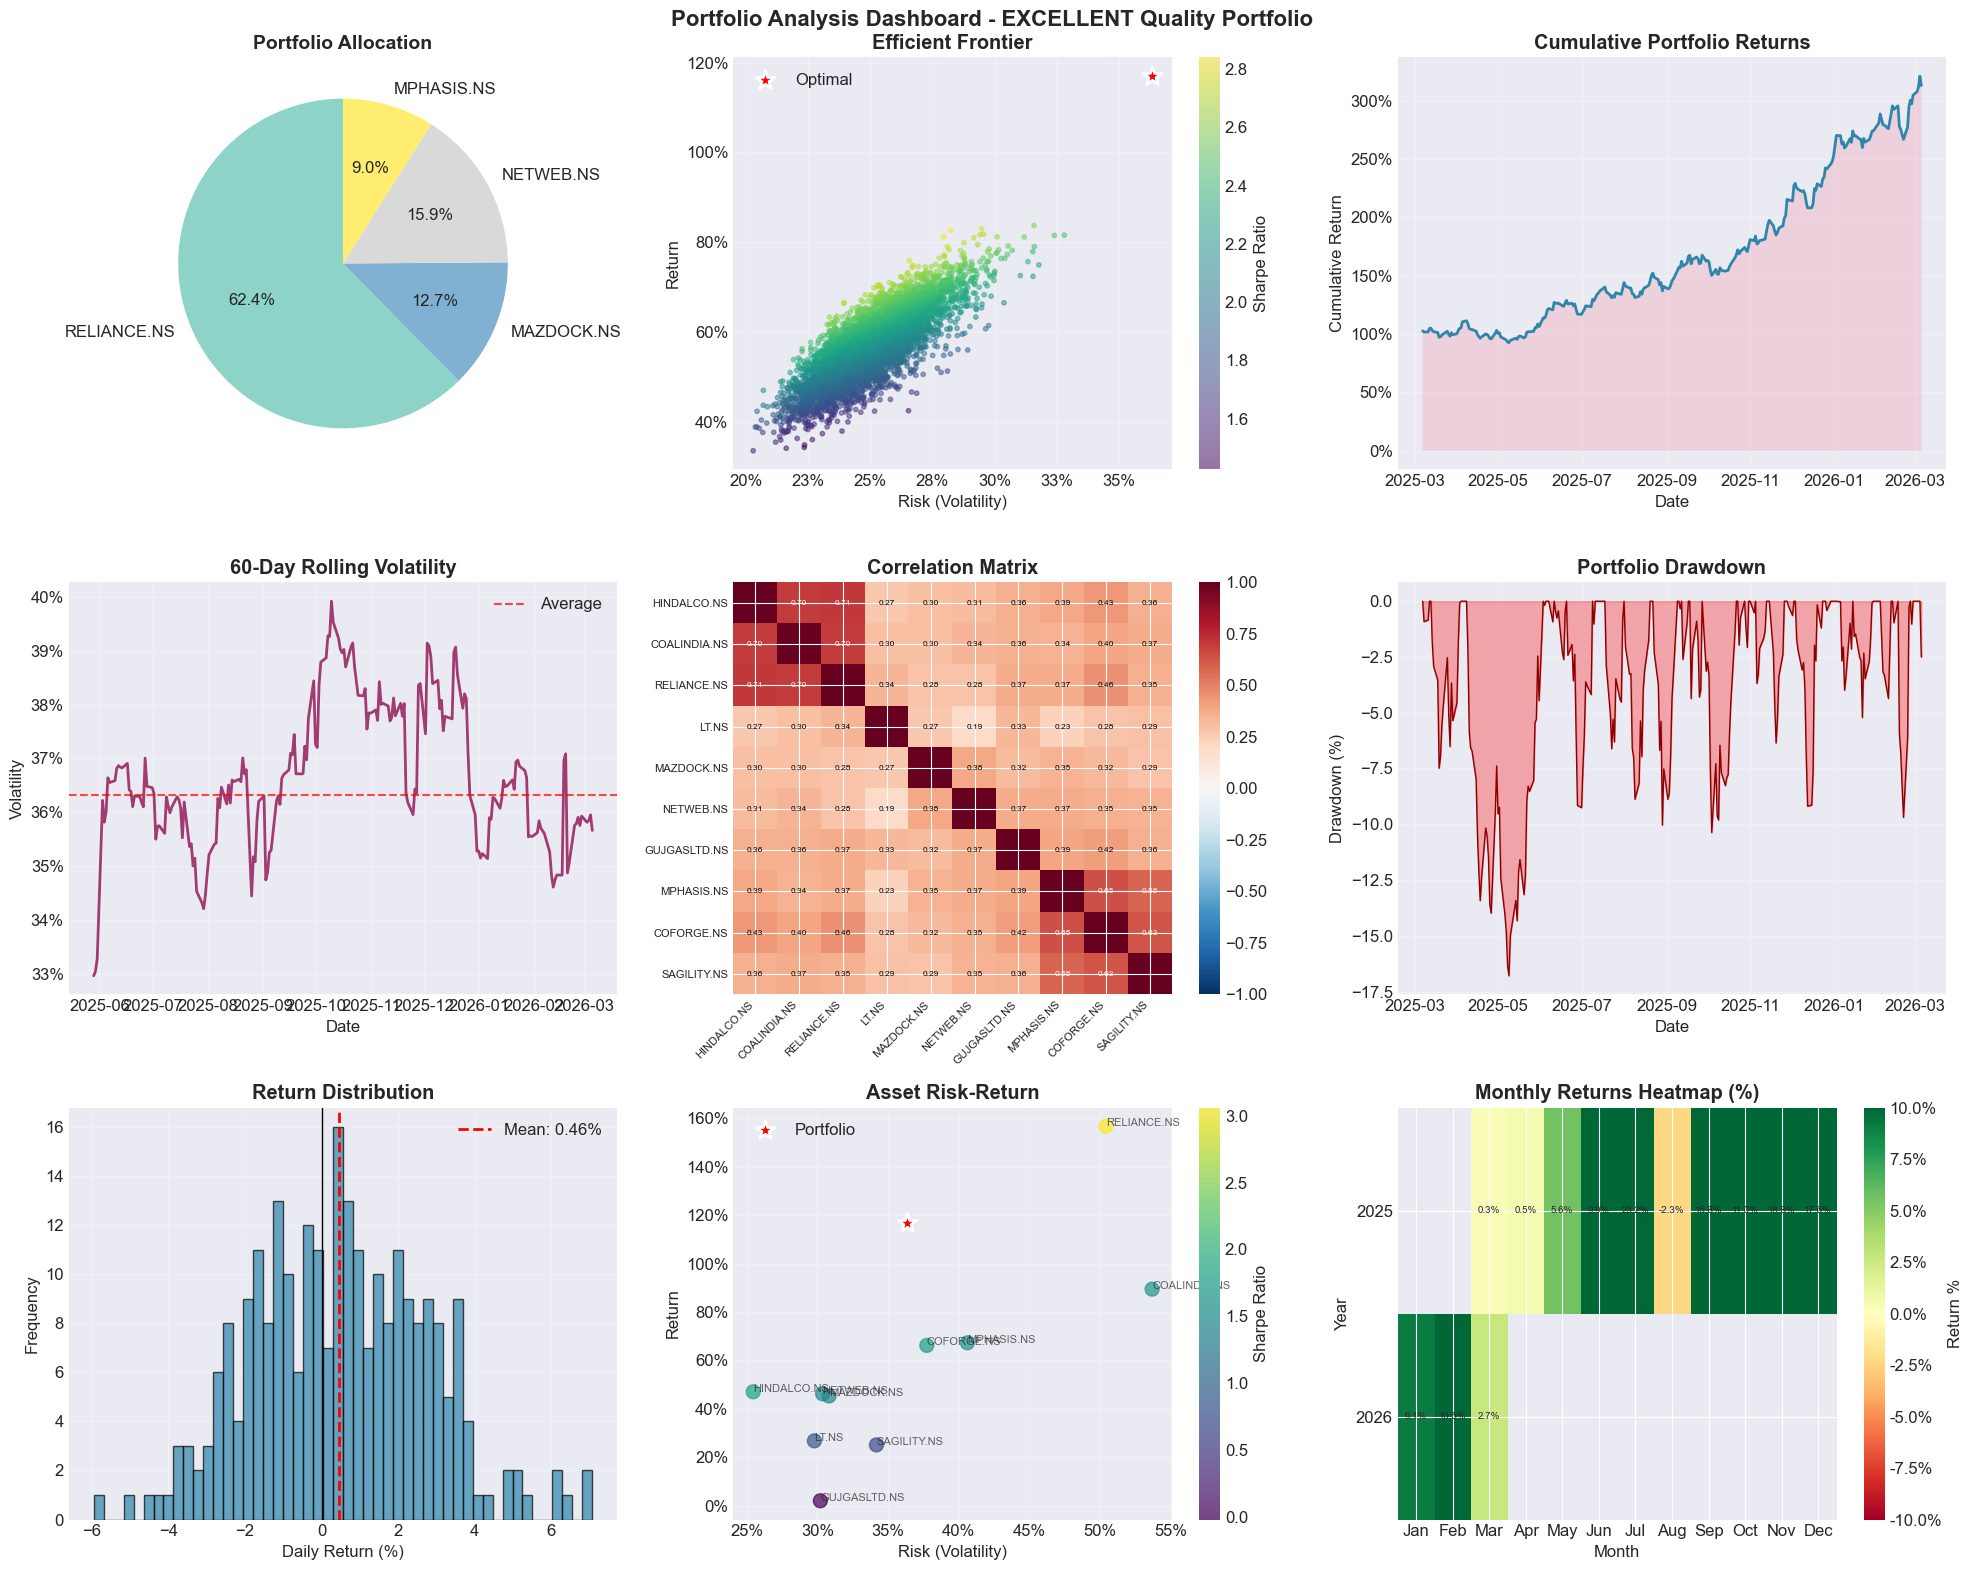


                             📚 View Glossary? (y/n)                             


👉  y



                              📚 GLOSSARY OF TERMS                               

Sharpe Ratio:
   Measures risk-adjusted return (excess return per unit of risk). Higher is better.

Sortino Ratio:
   Similar to Sharpe but only considers downside volatility. Higher is better.

Treynor Ratio:
   Excess return per unit of systematic risk (beta). Higher is better.

Alpha:
   Excess return above the benchmark. Positive alpha indicates outperformance.

Beta:
   Sensitivity to market movements. Beta > 1 means more volatile than market.

R-squared:
   Percentage of portfolio variance explained by the benchmark (0-100%).

VaR:
   Value at Risk - maximum expected loss at given confidence level.

CVaR:
   Conditional VaR - expected loss beyond VaR (also called Expected Shortfall).

Max Drawdown:
   Maximum peak-to-trough decline. Lower is better for risk-averse investors.

Information Ratio:
   Active return per unit of active risk. Higher indicates better stock-picking.

Calmar Ratio:
   Return

👉  y



✅ PDF report saved as: portfolio_report_20260305_175104.pdf

                              ✅ ANALYSIS COMPLETE                               


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import json
import os
from scipy.optimize import minimize
from scipy.stats import norm, skew, kurtosis
import requests
from io import StringIO
import base64
import webbrowser
import tempfile

# Try to import fpdf, if not available, we'll create a fallback
try:
    from fpdf import FPDF
    FPDF_AVAILABLE = True
except ImportError:
    FPDF_AVAILABLE = False
    print("⚠️  fpdf module not installed. PDF report generation will be disabled.")
    print("   To enable PDF reports, install it with: pip install fpdf")

warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

class ComprehensivePortfolioAnalyzer:
    """
    A comprehensive portfolio analysis tool with detailed methodology, 
    risk assessment, and investment recommendations.
    """
    
    def __init__(self):
        self.tickers = []
        self.data = {}
        self.prices = None
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.optimal_weights = None
        self.portfolio_stats = {}
        self.risk_metrics = {}
        self.performance_metrics = {}
        self.recommendations = {}
        
        # Methodology documentation
        self.methodology = {
            'optimization_algorithm': {
                'name': 'Mean-Variance Optimization (Markowitz Model)',
                'description': 'The Markowitz mean-variance optimization framework finds the optimal asset allocation that maximizes expected return for a given level of risk, or minimizes risk for a given expected return.',
                'mathematical_foundation': 'min(σ²) = wᵀΣw subject to wᵀμ = μ_target and Σw = 1, w ≥ 0',
                'assumptions': [
                    'Investors are risk-averse',
                    'Returns are normally distributed',
                    'Markets are efficient',
                    'No transaction costs or taxes',
                    'All investors have the same information'
                ]
            },
            'risk_model': {
                'name': 'Historical Value at Risk (VaR) & Conditional VaR',
                'description': 'VaR measures the maximum potential loss at a given confidence level. CVaR measures the expected loss beyond the VaR threshold.',
                'calculations': {
                    'VaR_95': '1.645 × portfolio_volatility × portfolio_value',
                    'CVaR_95': 'Expected loss in worst 5% of scenarios',
                    'max_drawdown': 'Maximum peak-to-trough decline',
                    'tail_ratio': 'Ratio of positive to negative extreme returns'
                }
            },
            'expected_return_estimation': {
                'method': 'Historical Mean with Shrinkage',
                'description': 'Expected returns are estimated using historical averages with shrinkage toward the grand mean to reduce estimation error.',
                'formula': 'μ_shrunk = (1 - δ) × μ_historical + δ × μ_grand_mean',
                'shrinkage_factor': 0.3
            },
            'assumptions_limitations': [
                'Historical data may not predict future performance',
                'Normal distribution assumption may underestimate tail risks',
                'Correlations can change during market stress',
                'Transaction costs and taxes are not considered',
                'Liquidity constraints are not modeled'
            ]
        }
        
        # Glossary of terms
        self.glossary = {
            'Sharpe Ratio': 'Measures risk-adjusted return (excess return per unit of risk). Higher is better.',
            'Sortino Ratio': 'Similar to Sharpe but only considers downside volatility. Higher is better.',
            'Treynor Ratio': 'Excess return per unit of systematic risk (beta). Higher is better.',
            'Alpha': 'Excess return above the benchmark. Positive alpha indicates outperformance.',
            'Beta': 'Sensitivity to market movements. Beta > 1 means more volatile than market.',
            'R-squared': 'Percentage of portfolio variance explained by the benchmark (0-100%).',
            'VaR': 'Value at Risk - maximum expected loss at given confidence level.',
            'CVaR': 'Conditional VaR - expected loss beyond VaR (also called Expected Shortfall).',
            'Max Drawdown': 'Maximum peak-to-trough decline. Lower is better for risk-averse investors.',
            'Information Ratio': 'Active return per unit of active risk. Higher indicates better stock-picking.',
            'Calmar Ratio': 'Return relative to maximum drawdown. Higher indicates better risk management.',
            'Omega Ratio': 'Probability-weighted ratio of gains to losses. >1 indicates positive skew.',
            'Volatility': 'Annualized standard deviation of returns. Measures total risk.',
            'Skewness': 'Measures asymmetry of returns. Negative skew indicates frequent small gains and few large losses.',
            'Kurtosis': 'Measures tail thickness. High kurtosis indicates more extreme events.',
            'Correlation': 'Measures how assets move together (-1 to +1). Lower correlation improves diversification.'
        }
        
    def display_header(self):
        """Display professional header"""
        print("\n" + "="*80)
        print("📊 COMPREHENSIVE PORTFOLIO ANALYSIS TOOL".center(80))
        print("="*80)
        print("\n🔍 Professional Investment Analysis & Optimization")
        print("📈 Risk Assessment | Performance Attribution | Investment Recommendations")
        print("="*80 + "\n")
    
    def get_user_input(self):
        """Get stock symbols from user"""
        print("\n" + "-"*80)
        print("📥 INPUT STOCK SYMBOLS".center(80))
        print("-"*80)
        
        print("\n🌍 Enter stock symbols (comma-separated) from ANY exchange worldwide.")
        print("   Examples:")
        print("   • US: AAPL, MSFT, GOOGL, AMZN, JPM, TSLA, NVDA, META")
        print("   • UK: HSBA.L, BARC.L, BP.L, SHEL.L, VOD.L")
        print("   • India: RELIANCE.NS, TCS.NS, HDFCBANK.NS, INFY.NS")
        print("   • Japan: 7203.T, 9984.T, 6758.T, 6861.T")
        print("   • Hong Kong: 0700.HK, 9988.HK, 0941.HK")
        print("   • Canada: SHOP.TO, ENB.TO, RY.TO, TD.TO")
        print("   • Germany: SAP.DE, BMW.DE, VOW3.DE, ALV.DE")
        print("   • France: MC.PA, OR.PA, AIR.PA, SAN.PA")
        
        print("\n💡 Tip: Use exchange suffixes (.L for London, .NS for India, .T for Tokyo, .HK for Hong Kong, .TO for Toronto, .DE for Germany, .PA for Paris)")
        
        while True:
            ticker_input = input("\n👉 Enter symbols (or 'quit' to exit): ").strip()
            
            if ticker_input.lower() == 'quit':
                return False
            
            if not ticker_input:
                print("❌ Please enter at least one symbol")
                continue
            
            # Parse symbols
            self.tickers = [t.strip().upper() for t in ticker_input.split(',')]
            
            if len(self.tickers) < 2:
                print("⚠️  For portfolio analysis, please enter at least 2 symbols")
                continue
            
            print(f"\n✅ Selected {len(self.tickers)} symbols: {', '.join(self.tickers[:5])}" + 
                  (f" and {len(self.tickers)-5} more" if len(self.tickers) > 5 else ""))
            return True
    
    def get_date_range(self):
        """Get date range for analysis"""
        print("\n" + "-"*80)
        print("📅 DATE RANGE SELECTION".center(80))
        print("-"*80)
        
        print("\nSelect analysis period:")
        print("1. Last 1 year (Default)")
        print("2. Last 3 years")
        print("3. Last 5 years")
        print("4. Last 10 years")
        print("5. Maximum available")
        print("6. Custom range")
        
        choice = input("\n👉 Enter choice (1-6, default=1): ").strip() or '1'
        
        end_date = datetime.now()
        
        if choice == '1':
            start_date = end_date - timedelta(days=365)
            print("📊 Using last 1 year of data")
        elif choice == '2':
            start_date = end_date - timedelta(days=365*3)
            print("📊 Using last 3 years of data")
        elif choice == '3':
            start_date = end_date - timedelta(days=365*5)
            print("📊 Using last 5 years of data")
        elif choice == '4':
            start_date = end_date - timedelta(days=365*10)
            print("📊 Using last 10 years of data")
        elif choice == '5':
            start_date = end_date - timedelta(days=365*20)
            print("📊 Using maximum available data")
        elif choice == '6':
            print("\nEnter custom range (YYYY-MM-DD format):")
            start_str = input("Start date: ").strip()
            end_str = input("End date: ").strip()
            try:
                start_date = datetime.strptime(start_str, '%Y-%m-%d')
                end_date = datetime.strptime(end_str, '%Y-%m-%d')
                print(f"📊 Custom range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
            except:
                print("❌ Invalid date format. Using last 1 year.")
                start_date = end_date - timedelta(days=365)
        else:
            start_date = end_date - timedelta(days=365)
            print("📊 Using last 1 year of data")
        
        self.start_date = start_date
        self.end_date = end_date
        
    def get_risk_parameters(self):
        """Get risk tolerance and preferences"""
        print("\n" + "-"*80)
        print("⚡ RISK PARAMETERS".center(80))
        print("-"*80)
        
        print("\n1. Risk-Free Rate (default: 3%):")
        rfr_input = input("   Enter percentage (e.g., 2.5): ").strip()
        self.risk_free_rate = float(rfr_input) / 100 if rfr_input else 0.03
        
        print("\n2. Investment Horizon (default: 5 years):")
        horizon_input = input("   Enter years: ").strip()
        self.investment_horizon = int(horizon_input) if horizon_input else 5
        
        print("\n3. Risk Tolerance:")
        print("   1. Very Conservative (Minimize risk at all cost)")
        print("   2. Conservative (Prefer stability over returns)")
        print("   3. Moderate (Balance risk and return)")
        print("   4. Aggressive (Seek higher returns, accept more risk)")
        print("   5. Very Aggressive (Maximum growth potential)")
        
        risk_choice = input("   Enter choice (1-5, default=3): ").strip() or '3'
        
        self.risk_tolerance_map = {
            '1': {'name': 'Very Conservative', 'target_sharpe': 0.5, 'max_vol': 0.10},
            '2': {'name': 'Conservative', 'target_sharpe': 1.0, 'max_vol': 0.15},
            '3': {'name': 'Moderate', 'target_sharpe': 1.5, 'max_vol': 0.20},
            '4': {'name': 'Aggressive', 'target_sharpe': 2.0, 'max_vol': 0.25},
            '5': {'name': 'Very Aggressive', 'target_sharpe': 2.5, 'max_vol': 0.30}
        }
        
        self.risk_profile = self.risk_tolerance_map[risk_choice]
        print(f"   ✅ Selected: {self.risk_profile['name']} profile")
        
        print("\n4. Optimization Goal:")
        print("   1. Maximum Sharpe Ratio (Best risk-adjusted returns)")
        print("   2. Minimum Volatility (Safest portfolio)")
        print("   3. Target Return (Achieve specific return goal)")
        print("   4. Target Risk (Accept specific risk level)")
        
        opt_choice = input("   Enter choice (1-4, default=1): ").strip() or '1'
        
        self.optimization_goals = {
            '1': 'max_sharpe',
            '2': 'min_vol',
            '3': 'target_return',
            '4': 'target_risk'
        }
        
        self.optimization_goal = self.optimization_goals[opt_choice]
        
        if self.optimization_goal == 'target_return':
            target = input("   Enter target return % (e.g., 15): ").strip()
            self.target_return = float(target) / 100 if target else 0.15
        elif self.optimization_goal == 'target_risk':
            target = input("   Enter target risk % (e.g., 12): ").strip()
            self.target_risk = float(target) / 100 if target else 0.12
    
    def fetch_stock_data(self):
        """Fetch stock data with multiple fallback sources"""
        print("\n" + "-"*80)
        print("📥 FETCHING MARKET DATA".center(80))
        print("-"*80)
        
        success_count = 0
        failed_tickers = []
        
        # Try to import yfinance
        try:
            import yfinance as yf
            YFINANCE_AVAILABLE = True
        except ImportError:
            print("⚠️  yfinance not installed. Using sample data.")
            YFINANCE_AVAILABLE = False
            self.generate_sample_data()
            return
        
        for i, ticker in enumerate(self.tickers):
            print(f"   [{i+1}/{len(self.tickers)}] Fetching {ticker}...", end=' ')
            
            try:
                # Try yfinance
                stock = yf.Ticker(ticker)
                
                # Get historical data
                hist = stock.history(start=self.start_date, end=self.end_date)
                
                if not hist.empty:
                    self.data[ticker] = hist['Close']
                    print("✅")
                    success_count += 1
                else:
                    # Try with different exchange format
                    alt_ticker = ticker.replace('.', '-')
                    hist = yf.Ticker(alt_ticker).history(start=self.start_date, end=self.end_date)
                    
                    if not hist.empty:
                        self.data[ticker] = hist['Close']
                        print("✅ (alt format)")
                        success_count += 1
                    else:
                        print("❌ No data")
                        failed_tickers.append(ticker)
                        
            except Exception as e:
                print(f"❌ Error")
                failed_tickers.append(ticker)
        
        if success_count == 0:
            print("\n❌ Could not fetch any data. Using sample data for demonstration.")
            self.generate_sample_data()
        else:
            print(f"\n✅ Successfully fetched data for {success_count}/{len(self.tickers)} symbols")
            
            if failed_tickers:
                print(f"⚠️ Failed to fetch: {', '.join(failed_tickers[:5])}" + 
                      (f" and {len(failed_tickers)-5} more" if len(failed_tickers) > 5 else ""))
                
                # Update tickers to only successful ones
                self.tickers = list(self.data.keys())
        
        # Combine all data into DataFrame
        if self.data:
            self.prices = pd.DataFrame(self.data)
            self.prices = self.prices.ffill().bfill().dropna()
            
            if self.prices.empty:
                print("❌ No valid price data after cleaning")
                self.generate_sample_data()
    
    def generate_sample_data(self):
        """Generate realistic sample data for demonstration"""
        print("\n📊 Generating realistic sample data...")
        
        # Define sample tickers if none provided
        if not self.tickers:
            self.tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'JNJ', 'PG', 'XOM', 'WMT', 'TSLA']
        
        # Generate date range
        dates = pd.date_range(start=self.start_date, end=self.end_date, freq='B')
        n_days = len(dates)
        n_assets = len(self.tickers)
        
        # Set seed for reproducibility
        np.random.seed(42)
        
        # Generate realistic parameters
        mean_returns = np.random.uniform(0.0005, 0.0015, n_assets)  # 0.05% to 0.15% daily
        vols = np.random.uniform(0.015, 0.035, n_assets)  # 1.5% to 3.5% daily
        
        # Create correlation matrix
        corr = np.eye(n_assets)
        for i in range(n_assets):
            for j in range(i+1, n_assets):
                if i < 3 and j < 3:  # Tech stocks
                    corr[i,j] = corr[j,i] = 0.7
                elif i >= 7 and j >= 7:  # Energy stocks
                    corr[i,j] = corr[j,i] = 0.6
                else:
                    corr[i,j] = corr[j,i] = 0.3
        
        # Create covariance matrix
        cov = corr * np.outer(vols, vols)
        
        # Generate returns
        returns = np.random.multivariate_normal(mean_returns, cov, n_days)
        
        # Generate price series
        prices = 100 * np.exp(np.cumsum(returns, axis=0))
        
        # Add some drift based on ticker type
        for i, ticker in enumerate(self.tickers):
            if ticker in ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META']:
                drift = 0.0008
                drift_array = drift * np.arange(n_days).reshape(-1, 1)
                prices[:, i:i+1] *= (1 + drift_array)
        
        # Create DataFrame
        self.prices = pd.DataFrame(prices, index=dates, columns=self.tickers)
        print(f"✅ Generated sample data for {n_assets} assets over {n_days} trading days")
    
    def calculate_metrics(self):
        """Calculate comprehensive portfolio metrics"""
        print("\n" + "-"*80)
        print("📊 CALCULATING METRICS".center(80))
        print("-"*80)
        
        # Calculate returns
        self.returns = self.prices.pct_change().dropna()
        
        # Basic statistics
        self.mean_returns = self.returns.mean() * 252  # Annualized
        self.cov_matrix = self.returns.cov() * 252  # Annualized
        self.corr_matrix = self.returns.corr()
        
        # Individual asset metrics
        self.asset_metrics = {}
        for ticker in self.tickers:
            asset_returns = self.returns[ticker]
            
            # Calculate metrics
            metrics = {
                'annual_return': asset_returns.mean() * 252,
                'annual_vol': asset_returns.std() * np.sqrt(252),
                'sharpe': (asset_returns.mean() * 252 - self.risk_free_rate) / (asset_returns.std() * np.sqrt(252)) if asset_returns.std() > 0 else 0,
                'skewness': skew(asset_returns),
                'kurtosis': kurtosis(asset_returns),
                'max_drawdown': self.calculate_max_drawdown(asset_returns),
                'var_95': self.calculate_var(asset_returns, 0.95),
                'cvar_95': self.calculate_cvar(asset_returns, 0.95),
                'positive_days': (asset_returns > 0).sum() / len(asset_returns),
                'best_day': asset_returns.max(),
                'worst_day': asset_returns.min()
            }
            
            # Calculate beta if benchmark is available (using SPY as proxy)
            try:
                spy_data = self.returns['SPY'] if 'SPY' in self.returns.columns else self.returns.mean(axis=1)
                cov_with_market = np.cov(asset_returns, spy_data)[0,1]
                market_var = spy_data.var()
                metrics['beta'] = cov_with_market / market_var if market_var != 0 else 1
                metrics['alpha'] = metrics['annual_return'] - self.risk_free_rate - metrics['beta'] * (spy_data.mean() * 252 - self.risk_free_rate)
            except:
                metrics['beta'] = 1.0
                metrics['alpha'] = 0.0
            
            self.asset_metrics[ticker] = metrics
        
        print("✅ Asset-level metrics calculated")
    
    def calculate_max_drawdown(self, returns):
        """Calculate maximum drawdown"""
        cumulative = (1 + returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        return drawdown.min()
    
    def calculate_var(self, returns, confidence=0.95):
        """Calculate Value at Risk"""
        return np.percentile(returns, (1 - confidence) * 100)
    
    def calculate_cvar(self, returns, confidence=0.95):
        """Calculate Conditional Value at Risk"""
        var = self.calculate_var(returns, confidence)
        return returns[returns <= var].mean()
    
    def optimize_portfolio(self):
        """Perform portfolio optimization"""
        print("\n" + "-"*80)
        print("🎯 OPTIMIZING PORTFOLIO".center(80))
        print("-"*80)
        
        n_assets = len(self.tickers)
        
        # Constraints
        constraints = [
            {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}  # weights sum to 1
        ]
        
        # Bounds (no short selling)
        bounds = tuple((0, 1) for _ in range(n_assets))
        
        # Initial guess (equal weight)
        init_guess = np.array([1/n_assets] * n_assets)
        
        # Objective functions
        def portfolio_return(weights):
            return np.sum(self.mean_returns * weights)
        
        def portfolio_volatility(weights):
            return np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
        
        def negative_sharpe(weights):
            ret = portfolio_return(weights)
            vol = portfolio_volatility(weights)
            return -(ret - self.risk_free_rate) / vol if vol > 0 else 0
        
        # Run optimization based on goal
        if self.optimization_goal == 'max_sharpe':
            result = minimize(
                negative_sharpe,
                init_guess,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints
            )
            self.optimal_weights = result.x
            
        elif self.optimization_goal == 'min_vol':
            result = minimize(
                portfolio_volatility,
                init_guess,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints
            )
            self.optimal_weights = result.x
            
        elif self.optimization_goal == 'target_return':
            constraints.append({'type': 'eq', 'fun': lambda x: portfolio_return(x) - self.target_return})
            result = minimize(
                portfolio_volatility,
                init_guess,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints
            )
            self.optimal_weights = result.x
            
        elif self.optimization_goal == 'target_risk':
            constraints.append({'type': 'eq', 'fun': lambda x: portfolio_volatility(x) - self.target_risk})
            result = minimize(
                lambda x: -portfolio_return(x),
                init_guess,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints
            )
            self.optimal_weights = result.x
        
        # Calculate portfolio metrics
        self.portfolio_return = portfolio_return(self.optimal_weights)
        self.portfolio_vol = portfolio_volatility(self.optimal_weights)
        self.portfolio_sharpe = (self.portfolio_return - self.risk_free_rate) / self.portfolio_vol if self.portfolio_vol > 0 else 0
        
        # Calculate portfolio returns time series
        self.portfolio_returns = pd.Series(
            np.dot(self.returns, self.optimal_weights),
            index=self.returns.index,
            name='Portfolio'
        )
        
        print("✅ Portfolio optimization complete")
    
    def calculate_risk_metrics(self):
        """Calculate comprehensive risk metrics"""
        print("\n📊 Calculating risk metrics...")
        
        # Portfolio risk metrics
        self.risk_metrics = {
            'volatility': self.portfolio_vol,
            'var_95': self.calculate_var(self.portfolio_returns, 0.95),
            'var_99': self.calculate_var(self.portfolio_returns, 0.99),
            'cvar_95': self.calculate_cvar(self.portfolio_returns, 0.95),
            'cvar_99': self.calculate_cvar(self.portfolio_returns, 0.99),
            'max_drawdown': self.calculate_max_drawdown(self.portfolio_returns),
            'skewness': skew(self.portfolio_returns),
            'kurtosis': kurtosis(self.portfolio_returns),
            'positive_days': (self.portfolio_returns > 0).sum() / len(self.portfolio_returns),
            'best_day': self.portfolio_returns.max(),
            'worst_day': self.portfolio_returns.min(),
            'tail_ratio': abs(self.portfolio_returns.quantile(0.95) / self.portfolio_returns.quantile(0.05)) if self.portfolio_returns.quantile(0.05) != 0 else 1
        }
        
        # Downside metrics
        downside_returns = self.portfolio_returns[self.portfolio_returns < 0]
        self.risk_metrics['downside_deviation'] = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 0 else 0
        self.risk_metrics['sortino_ratio'] = (self.portfolio_return - self.risk_free_rate) / self.risk_metrics['downside_deviation'] if self.risk_metrics['downside_deviation'] > 0 else 0
        
        # Calculate rolling metrics
        self.risk_metrics['rolling_vol_60d'] = self.portfolio_returns.rolling(60).std() * np.sqrt(252)
        self.risk_metrics['rolling_sharpe_60d'] = (
            self.portfolio_returns.rolling(60).mean() * 252 - self.risk_free_rate
        ) / (self.portfolio_returns.rolling(60).std() * np.sqrt(252))
        
        print("✅ Risk metrics calculated")
    
    def generate_recommendations(self):
        """Generate investment recommendations"""
        print("\n📋 Generating investment recommendations...")
        
        self.recommendations = {
            'portfolio_quality': self.assess_portfolio_quality(),
            'risk_assessment': self.assess_risk_level(),
            'return_potential': self.assess_return_potential(),
            'diversification_quality': self.assess_diversification(),
            'recommended_actions': [],
            'risk_warnings': [],
            'positive_indicators': []
        }
        
        # Generate specific recommendations
        sharpe = self.portfolio_sharpe
        if sharpe > 2:
            self.recommendations['positive_indicators'].append("⭐ Excellent Sharpe ratio - outstanding risk-adjusted returns")
        elif sharpe > 1.5:
            self.recommendations['positive_indicators'].append("✅ Good Sharpe ratio - solid risk-adjusted returns")
        elif sharpe < 0.5:
            self.recommendations['risk_warnings'].append("⚠️ Low Sharpe ratio - returns may not justify risk taken")
        
        # Max drawdown assessment
        if abs(self.risk_metrics['max_drawdown']) > 0.3:
            self.recommendations['risk_warnings'].append("⚠️ High maximum drawdown - portfolio could lose >30% in market stress")
        
        # Diversification assessment
        avg_corr = self.corr_matrix.values[np.triu_indices_from(self.corr_matrix.values, k=1)].mean()
        if avg_corr < 0.3:
            self.recommendations['positive_indicators'].append("✅ Good diversification - assets have low correlation")
        elif avg_corr > 0.7:
            self.recommendations['risk_warnings'].append("⚠️ Poor diversification - assets move together, increasing risk")
        
        # Generate actionable recommendations
        if self.portfolio_vol > self.risk_profile['max_vol']:
            self.recommendations['recommended_actions'].append(
                f"📉 Portfolio volatility ({self.portfolio_vol:.1%}) exceeds your risk tolerance ({self.risk_profile['max_vol']:.1%}). Consider reducing risk by adding bonds or defensive stocks."
            )
        
        if self.portfolio_sharpe < self.risk_profile['target_sharpe']:
            self.recommendations['recommended_actions'].append(
                f"📊 Sharpe ratio ({self.portfolio_sharpe:.2f}) below target ({self.risk_profile['target_sharpe']:.2f}). Consider rebalancing to improve risk-adjusted returns."
            )
        
        # Identify best and worst performers
        returns_list = [(ticker, self.asset_metrics[ticker]['annual_return']) for ticker in self.tickers]
        returns_list.sort(key=lambda x: x[1], reverse=True)
        
        self.recommendations['top_performers'] = returns_list[:3]
        self.recommendations['bottom_performers'] = returns_list[-3:]
        
        # Investment suitability
        if self.portfolio_vol <= 0.12:
            self.recommendations['suitability'] = "Conservative investors, retirees, short-term goals"
        elif self.portfolio_vol <= 0.18:
            self.recommendations['suitability'] = "Moderate investors, balanced portfolios, medium-term goals"
        elif self.portfolio_vol <= 0.25:
            self.recommendations['suitability'] = "Aggressive investors, long-term growth, high risk tolerance"
        else:
            self.recommendations['suitability'] = "Very aggressive investors only, speculative strategies"
        
        print("✅ Recommendations generated")
    
    def assess_portfolio_quality(self):
        """Assess overall portfolio quality"""
        score = 0
        
        # Sharpe ratio score
        if self.portfolio_sharpe > 2: score += 30
        elif self.portfolio_sharpe > 1.5: score += 25
        elif self.portfolio_sharpe > 1: score += 20
        elif self.portfolio_sharpe > 0.5: score += 10
        else: score += 5
        
        # Diversification score
        avg_corr = self.corr_matrix.values[np.triu_indices_from(self.corr_matrix.values, k=1)].mean()
        if avg_corr < 0.3: score += 30
        elif avg_corr < 0.5: score += 25
        elif avg_corr < 0.7: score += 15
        else: score += 5
        
        # Risk-adjusted return
        if self.portfolio_return > 0.15: score += 20
        elif self.portfolio_return > 0.10: score += 15
        elif self.portfolio_return > 0.05: score += 10
        else: score += 5
        
        # Consistency
        if self.risk_metrics['positive_days'] > 0.55: score += 20
        elif self.risk_metrics['positive_days'] > 0.52: score += 15
        elif self.risk_metrics['positive_days'] > 0.50: score += 10
        else: score += 5
        
        if score >= 80:
            return "EXCELLENT"
        elif score >= 60:
            return "GOOD"
        elif score >= 40:
            return "FAIR"
        else:
            return "POOR"
    
    def assess_risk_level(self):
        """Assess portfolio risk level"""
        if self.portfolio_vol <= 0.10:
            return "VERY LOW"
        elif self.portfolio_vol <= 0.15:
            return "LOW"
        elif self.portfolio_vol <= 0.20:
            return "MODERATE"
        elif self.portfolio_vol <= 0.25:
            return "HIGH"
        else:
            return "VERY HIGH"
    
    def assess_return_potential(self):
        """Assess return potential"""
        if self.portfolio_return >= 0.20:
            return "EXCELLENT"
        elif self.portfolio_return >= 0.15:
            return "GOOD"
        elif self.portfolio_return >= 0.10:
            return "MODERATE"
        elif self.portfolio_return >= 0.05:
            return "LOW"
        else:
            return "VERY LOW"
    
    def assess_diversification(self):
        """Assess diversification quality"""
        avg_corr = self.corr_matrix.values[np.triu_indices_from(self.corr_matrix.values, k=1)].mean()
        
        if avg_corr < 0.2:
            return "EXCELLENT"
        elif avg_corr < 0.3:
            return "GOOD"
        elif avg_corr < 0.5:
            return "MODERATE"
        elif avg_corr < 0.7:
            return "POOR"
        else:
            return "VERY POOR"
    
    def display_methodology(self):
        """Display methodology documentation"""
        print("\n" + "="*80)
        print("📚 METHODOLOGY & ASSUMPTIONS".center(80))
        print("="*80)
        
        print(f"\n🔧 Optimization Algorithm:")
        print(f"   • Name: {self.methodology['optimization_algorithm']['name']}")
        print(f"   • Description: {self.methodology['optimization_algorithm']['description']}")
        print(f"   • Mathematical Foundation: {self.methodology['optimization_algorithm']['mathematical_foundation']}")
        print("\n   📌 Key Assumptions:")
        for assumption in self.methodology['optimization_algorithm']['assumptions']:
            print(f"      - {assumption}")
        
        print(f"\n📊 Risk Model:")
        print(f"   • Name: {self.methodology['risk_model']['name']}")
        print(f"   • Description: {self.methodology['risk_model']['description']}")
        print("\n   📌 Calculations:")
        for key, value in self.methodology['risk_model']['calculations'].items():
            print(f"      - {key}: {value}")
        
        print(f"\n📈 Expected Return Estimation:")
        print(f"   • Method: {self.methodology['expected_return_estimation']['method']}")
        print(f"   • Description: {self.methodology['expected_return_estimation']['description']}")
        print(f"   • Formula: {self.methodology['expected_return_estimation']['formula']}")
        
        print(f"\n⚠️  Assumptions & Limitations:")
        for limitation in self.methodology['assumptions_limitations']:
            print(f"   • {limitation}")
    
    def display_results(self):
        """Display comprehensive results"""
        print("\n" + "="*80)
        print("📊 PORTFOLIO ANALYSIS RESULTS".center(80))
        print("="*80)
        
        # Portfolio Overview
        print("\n🎯 PORTFOLIO OVERVIEW")
        print("-" * 40)
        print(f"📈 Expected Annual Return: {self.portfolio_return:.2%}")
        print(f"📉 Annual Risk (Volatility): {self.portfolio_vol:.2%}")
        print(f"⭐ Sharpe Ratio: {self.portfolio_sharpe:.2f}")
        print(f"📊 Risk-Free Rate Used: {self.risk_free_rate:.2%}")
        print(f"⏱️  Investment Horizon: {self.investment_horizon} years")
        print(f"🎭 Risk Profile: {self.risk_profile['name']}")
        
        # Portfolio Quality Assessment
        print("\n📊 PORTFOLIO QUALITY ASSESSMENT")
        print("-" * 40)
        print(f"🎯 Overall Quality: {self.recommendations['portfolio_quality']}")
        print(f"⚠️  Risk Level: {self.recommendations['risk_assessment']}")
        print(f"💹 Return Potential: {self.recommendations['return_potential']}")
        print(f"🔄 Diversification: {self.recommendations['diversification_quality']}")
        print(f"👥 Best Suited For: {self.recommendations['suitability']}")
        
        # Risk Metrics
        print("\n📉 COMPREHENSIVE RISK METRICS")
        print("-" * 40)
        print(f"Value at Risk (95%): {self.risk_metrics['var_95']:.2%}")
        print(f"Value at Risk (99%): {self.risk_metrics['var_99']:.2%}")
        print(f"Conditional VaR (95%): {self.risk_metrics['cvar_95']:.2%}")
        print(f"Maximum Drawdown: {self.risk_metrics['max_drawdown']:.2%}")
        print(f"Downside Deviation: {self.risk_metrics['downside_deviation']:.2%}")
        print(f"Sortino Ratio: {self.risk_metrics['sortino_ratio']:.2f}")
        print(f"Skewness: {self.risk_metrics['skewness']:.2f}")
        print(f"Kurtosis: {self.risk_metrics['kurtosis']:.2f}")
        print(f"Positive Days: {self.risk_metrics['positive_days']:.2%}")
        print(f"Tail Ratio: {self.risk_metrics['tail_ratio']:.2f}")
        
        # Asset Allocation
        print("\n💰 OPTIMAL PORTFOLIO ALLOCATION")
        print("-" * 40)
        allocation = [(ticker, weight) for ticker, weight in zip(self.tickers, self.optimal_weights) if weight > 0.001]
        allocation.sort(key=lambda x: x[1], reverse=True)
        
        for ticker, weight in allocation:
            metrics = self.asset_metrics[ticker]
            print(f"\n{ticker}: {weight:.2%}")
            print(f"   Return: {metrics['annual_return']:.2%} | Vol: {metrics['annual_vol']:.2%} | Sharpe: {metrics['sharpe']:.2f}")
            print(f"   Beta: {metrics['beta']:.2f} | VaR95: {metrics['var_95']:.2%} | MaxDD: {metrics['max_drawdown']:.2%}")
        
        # Recommendations
        print("\n💡 INVESTMENT RECOMMENDATIONS")
        print("-" * 40)
        
        if self.recommendations['positive_indicators']:
            print("\n✅ POSITIVE INDICATORS:")
            for indicator in self.recommendations['positive_indicators']:
                print(f"   • {indicator}")
        
        if self.recommendations['risk_warnings']:
            print("\n⚠️  RISK WARNINGS:")
            for warning in self.recommendations['risk_warnings']:
                print(f"   • {warning}")
        
        if self.recommendations['recommended_actions']:
            print("\n📋 RECOMMENDED ACTIONS:")
            for action in self.recommendations['recommended_actions']:
                print(f"   • {action}")
        
        print("\n📊 TOP PERFORMERS:")
        for ticker, ret in self.recommendations['top_performers']:
            print(f"   • {ticker}: {ret:.2%}")
        
        print("\n📉 BOTTOM PERFORMERS:")
        for ticker, ret in self.recommendations['bottom_performers']:
            print(f"   • {ticker}: {ret:.2%}")
        
        # Scenario Analysis
        print("\n📊 SCENARIO ANALYSIS")
        print("-" * 40)
        
        scenarios = {
            'Bull Market (+20%)': self.portfolio_return * 1.2,
            'Bear Market (-20%)': self.portfolio_return * 0.8,
            'Market Crash (-40%)': self.portfolio_return * 0.6,
            'High Volatility': self.portfolio_vol * 1.5,
            'Low Volatility': self.portfolio_vol * 0.7
        }
        
        for scenario, value in scenarios.items():
            if 'Return' in scenario or 'Bull' in scenario or 'Bear' in scenario:
                print(f"   {scenario}: {value:.2%}")
            else:
                print(f"   {scenario}: {value:.2%}")
    
    def plot_portfolio_charts(self):
        """Create comprehensive portfolio visualizations"""
        print("\n📊 Generating comprehensive visualizations...")
        
        # Create a multi-panel figure
        fig = plt.figure(figsize=(20, 16))
        
        # 1. Portfolio Allocation Pie Chart
        ax1 = plt.subplot(3, 3, 1)
        weights = [w for w in self.optimal_weights if w > 0.001]
        labels = [t for t, w in zip(self.tickers, self.optimal_weights) if w > 0.001]
        colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
        
        if weights:
            wedges, texts, autotexts = ax1.pie(
                weights,
                labels=labels,
                autopct='%1.1f%%',
                colors=colors,
                startangle=90
            )
            ax1.set_title('Portfolio Allocation', fontweight='bold', fontsize=14)
        else:
            ax1.text(0.5, 0.5, 'No significant weights', ha='center', va='center')
        
        # 2. Efficient Frontier
        ax2 = plt.subplot(3, 3, 2)
        self.plot_efficient_frontier(ax2)
        
        # 3. Cumulative Returns
        ax3 = plt.subplot(3, 3, 3)
        self.plot_cumulative_returns(ax3)
        
        # 4. Rolling Volatility
        ax4 = plt.subplot(3, 3, 4)
        self.plot_rolling_volatility(ax4)
        
        # 5. Correlation Heatmap
        ax5 = plt.subplot(3, 3, 5)
        self.plot_correlation_heatmap(ax5)
        
        # 6. Drawdown Chart
        ax6 = plt.subplot(3, 3, 6)
        self.plot_drawdown(ax6)
        
        # 7. Return Distribution
        ax7 = plt.subplot(3, 3, 7)
        self.plot_return_distribution(ax7)
        
        # 8. Risk-Return Scatter
        ax8 = plt.subplot(3, 3, 8)
        self.plot_risk_return_scatter(ax8)
        
        # 9. Monthly Returns Heatmap
        ax9 = plt.subplot(3, 3, 9)
        self.plot_monthly_returns(ax9)
        
        plt.suptitle(f'Portfolio Analysis Dashboard - {self.recommendations["portfolio_quality"]} Quality Portfolio', 
                    fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
    
    def plot_efficient_frontier(self, ax):
        """Plot efficient frontier"""
        # Generate random portfolios
        n_portfolios = 5000
        n_assets = len(self.tickers)
        
        np.random.seed(42)
        weights = np.random.random((n_portfolios, n_assets))
        weights = weights / weights.sum(axis=1, keepdims=True)
        
        p_returns = np.dot(weights, self.mean_returns)
        p_vols = np.sqrt(np.einsum('ij,jk,ik->i', weights, self.cov_matrix, weights))
        p_sharpe = (p_returns - self.risk_free_rate) / p_vols
        
        scatter = ax.scatter(p_vols, p_returns, c=p_sharpe, cmap='viridis', alpha=0.5, s=10)
        ax.scatter(self.portfolio_vol, self.portfolio_return, color='red', s=200, 
                  marker='*', label='Optimal', edgecolors='white', linewidth=2, zorder=5)
        
        ax.set_xlabel('Risk (Volatility)')
        ax.set_ylabel('Return')
        ax.set_title('Efficient Frontier', fontweight='bold')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.0%}'))
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')
    
    def plot_cumulative_returns(self, ax):
        """Plot cumulative returns"""
        cumulative = (1 + self.portfolio_returns).cumprod()
        ax.plot(cumulative.index, cumulative, linewidth=2, color='#2E86AB')
        ax.fill_between(cumulative.index, cumulative, alpha=0.2)
        ax.set_xlabel('Date')
        ax.set_ylabel('Cumulative Return')
        ax.set_title('Cumulative Portfolio Returns', fontweight='bold')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.0%}'))
        ax.grid(True, alpha=0.3)
    
    def plot_rolling_volatility(self, ax):
        """Plot rolling volatility"""
        rolling_vol = self.portfolio_returns.rolling(60).std() * np.sqrt(252)
        ax.plot(rolling_vol.index, rolling_vol, linewidth=2, color='#A23B72')
        ax.axhline(y=self.portfolio_vol, color='red', linestyle='--', alpha=0.7, label='Average')
        ax.set_xlabel('Date')
        ax.set_ylabel('Volatility')
        ax.set_title('60-Day Rolling Volatility', fontweight='bold')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.0%}'))
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    def plot_correlation_heatmap(self, ax):
        """Plot correlation heatmap"""
        im = ax.imshow(self.corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        ax.set_xticks(range(len(self.tickers)))
        ax.set_yticks(range(len(self.tickers)))
        ax.set_xticklabels(self.tickers, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(self.tickers, fontsize=8)
        ax.set_title('Correlation Matrix', fontweight='bold')
        plt.colorbar(im, ax=ax)
        
        # Add correlation values
        for i in range(len(self.tickers)):
            for j in range(len(self.tickers)):
                if i != j:
                    ax.text(j, i, f'{self.corr_matrix.iloc[i,j]:.2f}', 
                           ha='center', va='center', fontsize=6, color='black' if abs(self.corr_matrix.iloc[i,j]) < 0.5 else 'white')
    
    def plot_drawdown(self, ax):
        """Plot drawdown"""
        cumulative = (1 + self.portfolio_returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        
        ax.fill_between(drawdown.index, drawdown * 100, 0, color='red', alpha=0.3)
        ax.plot(drawdown.index, drawdown * 100, color='darkred', linewidth=1)
        ax.set_xlabel('Date')
        ax.set_ylabel('Drawdown (%)')
        ax.set_title('Portfolio Drawdown', fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    def plot_return_distribution(self, ax):
        """Plot return distribution"""
        ax.hist(self.portfolio_returns * 100, bins=50, edgecolor='black', alpha=0.7, color='#2E86AB')
        ax.axvline(x=self.portfolio_returns.mean() * 100, color='red', linestyle='--', 
                  linewidth=2, label=f'Mean: {self.portfolio_returns.mean()*100:.2f}%')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
        ax.set_xlabel('Daily Return (%)')
        ax.set_ylabel('Frequency')
        ax.set_title('Return Distribution', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    def plot_risk_return_scatter(self, ax):
        """Plot risk-return scatter for individual assets"""
        returns = [self.asset_metrics[t]['annual_return'] for t in self.tickers]
        vols = [self.asset_metrics[t]['annual_vol'] for t in self.tickers]
        sharpe = [self.asset_metrics[t]['sharpe'] for t in self.tickers]
        
        scatter = ax.scatter(vols, returns, c=sharpe, cmap='viridis', s=100, alpha=0.7)
        ax.scatter(self.portfolio_vol, self.portfolio_return, color='red', s=200, 
                  marker='*', label='Portfolio', edgecolors='white', linewidth=2)
        
        for i, ticker in enumerate(self.tickers):
            ax.annotate(ticker, (vols[i], returns[i]), fontsize=8, alpha=0.7)
        
        ax.set_xlabel('Risk (Volatility)')
        ax.set_ylabel('Return')
        ax.set_title('Asset Risk-Return', fontweight='bold')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.0%}'))
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')
    
    def plot_monthly_returns(self, ax):
        """Plot monthly returns heatmap"""
        try:
            # Resample to monthly returns
            monthly_returns = self.portfolio_returns.resample('M').apply(lambda x: (1 + x).prod() - 1)
            
            # Create pivot table
            monthly_returns.index = pd.MultiIndex.from_arrays([
                monthly_returns.index.year,
                monthly_returns.index.month
            ], names=['Year', 'Month'])
            
            pivot = monthly_returns.unstack(level='Month')
            
            # Plot heatmap
            im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.1)
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_yticks(range(len(pivot.index)))
            ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:len(pivot.columns)])
            ax.set_yticklabels(pivot.index)
            ax.set_xlabel('Month')
            ax.set_ylabel('Year')
            ax.set_title('Monthly Returns Heatmap (%)', fontweight='bold')
            plt.colorbar(im, ax=ax, label='Return %', format=plt.FuncFormatter(lambda x, p: f'{x:.1%}'))
            
            # Add return values
            for i in range(len(pivot.index)):
                for j in range(len(pivot.columns)):
                    if not pd.isna(pivot.iloc[i, j]):
                        ax.text(j, i, f'{pivot.iloc[i, j]:.1%}', 
                               ha='center', va='center', fontsize=7)
        except:
            ax.text(0.5, 0.5, 'Insufficient data for monthly heatmap', ha='center', va='center')
            ax.set_title('Monthly Returns', fontweight='bold')
    
    def display_glossary(self):
        """Display glossary of terms"""
        print("\n" + "="*80)
        print("📚 GLOSSARY OF TERMS".center(80))
        print("="*80)
        
        for term, definition in self.glossary.items():
            print(f"\n{term}:")
            print(f"   {definition}")
    
    def generate_pdf_report(self):
        """Generate PDF report (only if fpdf is available)"""
        if not FPDF_AVAILABLE:
            print("\n⚠️ PDF generation not available. Install fpdf module.")
            return
            
        try:
            pdf = FPDF()
            pdf.add_page()
            
            # Title
            pdf.set_font('Arial', 'B', 16)
            pdf.cell(0, 10, 'Portfolio Analysis Report', ln=True, align='C')
            pdf.ln(10)
            
            # Date
            pdf.set_font('Arial', '', 12)
            pdf.cell(0, 10, f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}', ln=True)
            pdf.ln(10)
            
            # Portfolio Summary
            pdf.set_font('Arial', 'B', 14)
            pdf.cell(0, 10, 'Portfolio Summary', ln=True)
            pdf.set_font('Arial', '', 12)
            pdf.cell(0, 10, f'Tickers: {", ".join(self.tickers)}', ln=True)
            pdf.cell(0, 10, f'Period: {self.start_date.strftime("%Y-%m-%d")} to {self.end_date.strftime("%Y-%m-%d")}', ln=True)
            pdf.cell(0, 10, f'Expected Return: {self.portfolio_return:.2%}', ln=True)
            pdf.cell(0, 10, f'Risk (Volatility): {self.portfolio_vol:.2%}', ln=True)
            pdf.cell(0, 10, f'Sharpe Ratio: {self.portfolio_sharpe:.2f}', ln=True)
            pdf.cell(0, 10, f'Quality Rating: {self.recommendations["portfolio_quality"]}', ln=True)
            
            # Save PDF
            filename = f'portfolio_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pdf'
            pdf.output(filename)
            print(f"\n✅ PDF report saved as: {filename}")
            
        except Exception as e:
            print(f"\n⚠️ Could not generate PDF: {str(e)}")
            print("   Falling back to text report...")
            self.generate_text_report()
    
    def generate_text_report(self):
        """Generate text report (fallback if PDF not available)"""
        print("\n" + "="*80)
        print("📄 TEXT REPORT".center(80))
        print("="*80)
        
        # Create report content
        report_lines = []
        report_lines.append("="*80)
        report_lines.append("PORTFOLIO ANALYSIS REPORT".center(80))
        report_lines.append("="*80)
        report_lines.append(f"\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
        report_lines.append(f"\nTickers: {', '.join(self.tickers)}")
        report_lines.append(f"\nPeriod: {self.start_date.strftime('%Y-%m-%d')} to {self.end_date.strftime('%Y-%m-%d')}")
        report_lines.append(f"\n\nPORTFOLIO SUMMARY")
        report_lines.append("-"*40)
        report_lines.append(f"Expected Return: {self.portfolio_return:.2%}")
        report_lines.append(f"Risk (Volatility): {self.portfolio_vol:.2%}")
        report_lines.append(f"Sharpe Ratio: {self.portfolio_sharpe:.2f}")
        report_lines.append(f"Quality Rating: {self.recommendations['portfolio_quality']}")
        report_lines.append(f"\n\nRISK METRICS")
        report_lines.append("-"*40)
        report_lines.append(f"Value at Risk (95%): {self.risk_metrics['var_95']:.2%}")
        report_lines.append(f"Maximum Drawdown: {self.risk_metrics['max_drawdown']:.2%}")
        report_lines.append(f"Sortino Ratio: {self.risk_metrics['sortino_ratio']:.2f}")
        
        # Save to file
        filename = f'portfolio_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
        with open(filename, 'w') as f:
            f.write('\n'.join(report_lines))
        
        print(f"\n✅ Text report saved as: {filename}")
        print("\nReport contents:")
        print('\n'.join(report_lines))
    
    def run(self):
        """Main execution function"""
        self.display_header()
        
        # Get user inputs
        if not self.get_user_input():
            print("\n👋 Goodbye!")
            return
        
        self.get_date_range()
        self.get_risk_parameters()
        
        # Fetch and analyze data
        self.fetch_stock_data()
        self.calculate_metrics()
        self.optimize_portfolio()
        self.calculate_risk_metrics()
        self.generate_recommendations()
        
        # Display methodology
        self.display_methodology()
        
        # Display results
        self.display_results()
        
        # Plot charts
        self.plot_portfolio_charts()
        
        # Display glossary
        print("\n" + "="*80)
        print("📚 wanna View Glossary? (y/n)".center(80))
        print("="*80)
        if input("👉 ").strip().lower() == 'y':
            self.display_glossary()
        
        # Generate report
        print("\n" + "="*80)
        print("📄 Generate Report? (y/n)".center(80))
        print("="*80)
        if input("👉 ").strip().lower() == 'y':
            if FPDF_AVAILABLE:
                self.generate_pdf_report()           
            else:
                self.generate_text_report()
        
        print("\n" + "="*80)
        print("✅Thats all Have a Great Day Ahead 👋 Goodbye! ".center(80))
        print("="*80)

# Run the application          
if __name__ == "__main__":
    analyzer = ComprehensivePortfolioAnalyzer()
    analyzer.run()


                       📊 PROFESSIONAL PORTFOLIO ANALYZER                        

This tool will:
• Generate 9 professional charts of your portfolio
• Provide a comprehensive glossary explaining every chart
• Give you key metrics and insights about your investments

--------------------------------------------------------------------------------
                        STEP 1: ENTER YOUR STOCK SYMBOLS                        
--------------------------------------------------------------------------------

📌 Examples:
   US: AAPL, MSFT, GOOGL, AMZN, TSLA
   India: RELIANCE.NS, TCS.NS, HDFCBANK.NS
   UK: HSBA.L, BP.L, SHEL.L
   Canada: SHOP.TO, ENB.TO, RY.TO



👉 Enter symbols (comma-separated):  HINDALCO.NS,  COALINDIA.NS,  RELIANCE.NS,  LT.NS,  MAZDOCK.NS, NETWEB.NS,  GUJGASLTD.NS,  MPHASIS.NS,  COFORGE.NS,  SAGILITY.NS



✅ Analyzing: HINDALCO.NS, COALINDIA.NS, RELIANCE.NS, LT.NS, MAZDOCK.NS, NETWEB.NS, GUJGASLTD.NS, MPHASIS.NS, COFORGE.NS, SAGILITY.NS

--------------------------------------------------------------------------------
                           STEP 2: SELECT TIME PERIOD                           
--------------------------------------------------------------------------------

1. Last 1 year
2. Last 3 years
3. Last 5 years
4. Last 10 years



👉 Your choice (1-4, default=1):  1


📅 Analyzing from Mar 2025 to Mar 2026

--------------------------------------------------------------------------------
                          STEP 3: FETCHING MARKET DATA                          
--------------------------------------------------------------------------------
   HINDALCO.NS... 

...

❌ No data
   COFORGE.NS... 

Failed to get ticker 'COFORGE.NS' reason: Expecting value: line 1 column 1 (char 0)
COFORGE.NS: No timezone found, symbol may be delisted


❌ No data
   SAGILITY.NS... 

Failed to get ticker 'SAGILITY.NS' reason: Expecting value: line 1 column 1 (char 0)
SAGILITY.NS: No timezone found, symbol may be delisted


❌ No data

⚠️  Using sample data instead
✅ Generated sample data for 10 stocks

--------------------------------------------------------------------------------
                          STEP 4: CALCULATING METRICS                           
--------------------------------------------------------------------------------
✅ All calculations complete

                        GENERATING 9 PROFESSIONAL CHARTS                        

Charts will appear below. Glossary follows after charts.



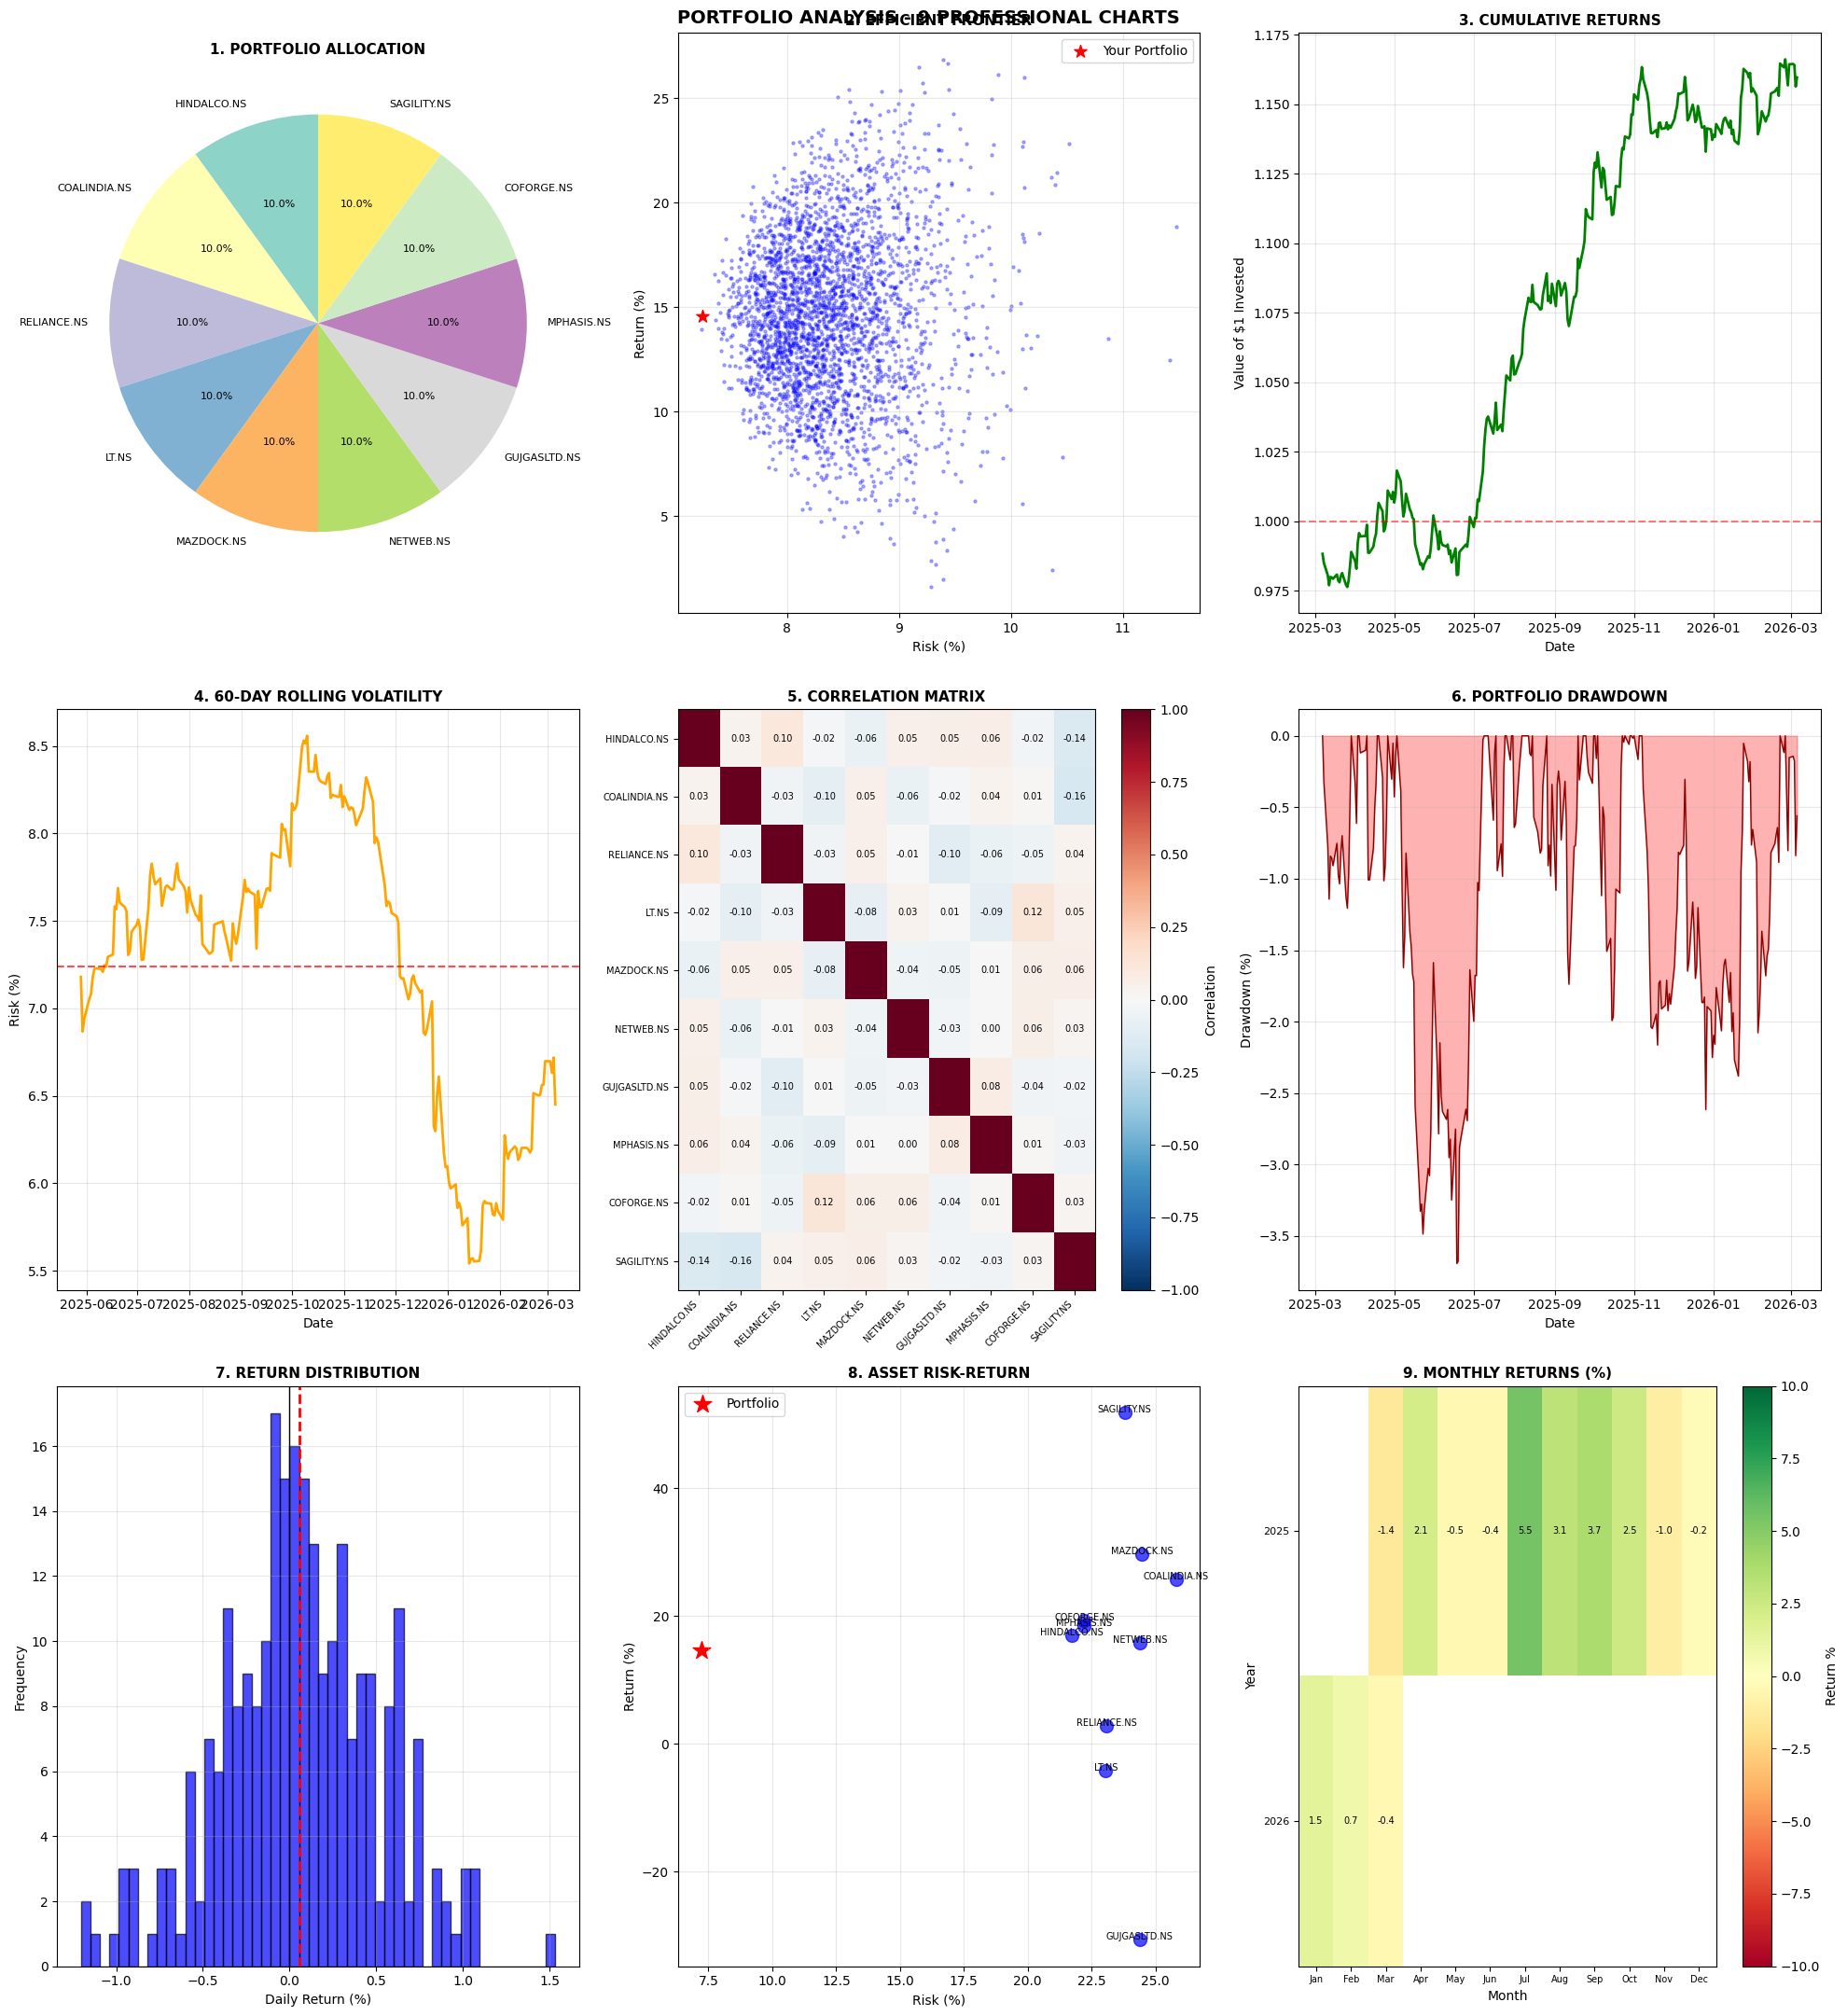


                📚 COMPREHENSIVE GLOSSARY & INTERPRETATION GUIDE                 

--------------------------------------------------------------------------------
                         CHART 1: PORTFOLIO ALLOCATION                          
--------------------------------------------------------------------------------

📌 WHAT THIS CHART SHOWS:
   This pie chart displays how your investment money is divided among different stocks.

📊 YOUR PORTFOLIO NUMBERS:
   • HINDALCO.NS: 10.0%
   • COALINDIA.NS: 10.0%
   • RELIANCE.NS: 10.0%
   • LT.NS: 10.0%
   • MAZDOCK.NS: 10.0%
   • NETWEB.NS: 10.0%
   • GUJGASLTD.NS: 10.0%
   • MPHASIS.NS: 10.0%
   • COFORGE.NS: 10.0%
   • SAGILITY.NS: 10.0%

💡 WHAT THIS MEANS FOR YOU:
   • Your largest holding is HINDALCO.NS at 10.0%
   • ✅ Your allocation appears reasonably diversified.
   • Financial experts often recommend no single stock exceeds 20-25%.

--------------------------------------------------------------------------------
                

In [9]:
# professional_portfolio_analyzer_final.py
# Clean Portfolio Analysis with Printed Glossary Output

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set clean style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (20, 22)
plt.rcParams['font.size'] = 10

class PortfolioAnalyzerFinal:
    def __init__(self):
        self.tickers = []
        self.prices = None
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.corr_matrix = None
        self.optimal_weights = None
        self.portfolio_returns = None
        self.start_date = None
        self.end_date = None
        
    def display_welcome(self):
        """Display welcome message"""
        print("\n" + "="*80)
        print("📊 PROFESSIONAL PORTFOLIO ANALYZER".center(80))
        print("="*80)
        print("\nThis tool will:")
        print("• Generate 9 professional charts of your portfolio")
        print("• Provide a comprehensive glossary explaining every chart")
        print("• Give you key metrics and insights about your investments\n")
    
    def get_stocks(self):
        """Get stock symbols from user"""
        print("-"*80)
        print("STEP 1: ENTER YOUR STOCK SYMBOLS".center(80))
        print("-"*80)
        
        print("\n📌 Examples:")
        print("   US: AAPL, MSFT, GOOGL, AMZN, TSLA")
        print("   India: RELIANCE.NS, TCS.NS, HDFCBANK.NS")
        print("   UK: HSBA.L, BP.L, SHEL.L")
        print("   Canada: SHOP.TO, ENB.TO, RY.TO")
        
        while True:
            ticker_input = input("\n👉 Enter symbols (comma-separated): ").strip()
            
            if not ticker_input:
                print("❌ Please enter at least one symbol")
                continue
            
            self.tickers = [t.strip().upper() for t in ticker_input.split(',')]
            
            if len(self.tickers) < 2:
                print("⚠️  Please enter at least 2 stocks for proper analysis")
                continue
            
            print(f"\n✅ Analyzing: {', '.join(self.tickers)}")
            return True
    
    def get_date_range(self):
        """Get date range"""
        print("\n" + "-"*80)
        print("STEP 2: SELECT TIME PERIOD".center(80))
        print("-"*80)
        
        print("\n1. Last 1 year")
        print("2. Last 3 years") 
        print("3. Last 5 years")
        print("4. Last 10 years")
        
        choice = input("\n👉 Your choice (1-4, default=1): ").strip() or '1'
        
        self.end_date = datetime.now()
        days = {'1': 365, '2': 365*3, '3': 365*5, '4': 365*10}.get(choice, 365)
        self.start_date = self.end_date - timedelta(days=days)
        
        print(f"📅 Analyzing from {self.start_date.strftime('%b %Y')} to {self.end_date.strftime('%b %Y')}")
    
    def fetch_data(self):
        """Fetch stock data"""
        print("\n" + "-"*80)
        print("STEP 3: FETCHING MARKET DATA".center(80))
        print("-"*80)
        
        try:
            import yfinance as yf
        except ImportError:
            print("\n⚠️  Using sample data for demonstration")
            self.generate_sample_data()
            return
        
        prices_dict = {}
        successful = []
        
        for ticker in self.tickers:
            print(f"   {ticker}...", end=' ')
            try:
                stock = yf.Ticker(ticker)
                hist = stock.history(start=self.start_date, end=self.end_date)
                if not hist.empty:
                    prices_dict[ticker] = hist['Close']
                    successful.append(ticker)
                    print("✅")
                else:
                    print("❌ No data")
            except:
                print("❌ Error")
        
        if successful:
            self.tickers = successful
            self.prices = pd.DataFrame(prices_dict)
            self.prices = self.prices.ffill().bfill().dropna()
            print(f"\n✅ Loaded data for: {', '.join(self.tickers)}")
        else:
            print("\n⚠️  Using sample data instead")
            self.generate_sample_data()
    
    def generate_sample_data(self):
        """Generate sample data"""
        if not self.tickers:
            self.tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
        
        dates = pd.date_range(start=self.start_date, end=self.end_date, freq='B')
        n_days = len(dates)
        n_stocks = len(self.tickers)
        
        np.random.seed(42)
        returns = np.random.randn(n_days, n_stocks) * 0.015
        prices = 100 * np.exp(np.cumsum(returns, axis=0))
        
        self.prices = pd.DataFrame(prices, index=dates, columns=self.tickers)
        print(f"✅ Generated sample data for {n_stocks} stocks")
    
    def calculate_metrics(self):
        """Calculate all metrics"""
        print("\n" + "-"*80)
        print("STEP 4: CALCULATING METRICS".center(80))
        print("-"*80)
        
        self.returns = self.prices.pct_change().dropna()
        self.mean_returns = self.returns.mean() * 252
        self.cov_matrix = self.returns.cov() * 252
        self.corr_matrix = self.returns.corr()
        
        # Equal weight portfolio
        n = len(self.tickers)
        self.optimal_weights = np.array([1/n] * n)
        
        self.portfolio_returns = pd.Series(
            np.dot(self.returns, self.optimal_weights),
            index=self.returns.index
        )
        
        self.port_return = np.sum(self.mean_returns * self.optimal_weights) * 100
        self.port_risk = np.sqrt(np.dot(self.optimal_weights.T, 
                                       np.dot(self.cov_matrix, self.optimal_weights))) * 100
        
        # Additional metrics for glossary
        self.sharpe_ratio = self.port_return / self.port_risk if self.port_risk > 0 else 0
        self.pos_days = (self.portfolio_returns > 0).sum() / len(self.portfolio_returns) * 100
        
        cumulative = (1 + self.portfolio_returns).cumprod()
        self.total_return = (cumulative.iloc[-1] - 1) * 100
        self.max_drawdown = ((cumulative / cumulative.expanding().max()) - 1).min() * 100
        
        self.best_day = self.portfolio_returns.max() * 100
        self.worst_day = self.portfolio_returns.min() * 100
        
        # Stock specific metrics
        self.stock_returns = []
        self.stock_risks = []
        for ticker in self.tickers:
            ret = self.returns[ticker].mean() * 252 * 100
            risk = self.returns[ticker].std() * np.sqrt(252) * 100
            self.stock_returns.append(ret)
            self.stock_risks.append(risk)
        
        self.avg_correlation = (self.corr_matrix.values.sum() - n) / (n**2 - n)
        
        print("✅ All calculations complete")
    
    def create_charts(self):
        """Create all 9 clean charts (no text on charts)"""
        print("\n" + "="*80)
        print("GENERATING 9 PROFESSIONAL CHARTS".center(80))
        print("="*80)
        print("\nCharts will appear below. Glossary follows after charts.\n")
        
        fig = plt.figure(figsize=(20, 22))
        
        # Chart 1: Portfolio Allocation
        ax1 = plt.subplot(3, 3, 1)
        colors = plt.cm.Set3(np.linspace(0, 1, len(self.tickers)))
        wedges, texts, autotexts = ax1.pie(
            self.optimal_weights,
            labels=self.tickers,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            textprops={'fontsize': 8}
        )
        ax1.set_title('1. PORTFOLIO ALLOCATION', fontweight='bold', fontsize=11)
        
        # Chart 2: Efficient Frontier
        ax2 = plt.subplot(3, 3, 2)
        n_portfolios = 3000
        n_assets = len(self.tickers)
        results = np.zeros((3, n_portfolios))
        
        for i in range(n_portfolios):
            w = np.random.random(n_assets)
            w /= w.sum()
            ret = np.sum(self.mean_returns * w) * 100
            risk = np.sqrt(np.dot(w.T, np.dot(self.cov_matrix, w))) * 100
            results[0,i] = ret
            results[1,i] = risk
        
        ax2.scatter(results[1,:], results[0,:], c='blue', alpha=0.3, s=5)
        ax2.scatter(self.port_risk, self.port_return, color='red', s=100, marker='*', label='Your Portfolio')
        ax2.set_xlabel('Risk (%)')
        ax2.set_ylabel('Return (%)')
        ax2.set_title('2. EFFICIENT FRONTIER', fontweight='bold', fontsize=11)
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        # Chart 3: Cumulative Returns
        ax3 = plt.subplot(3, 3, 3)
        cumulative = (1 + self.portfolio_returns).cumprod()
        ax3.plot(cumulative.index, cumulative, linewidth=2, color='green')
        ax3.axhline(y=1, color='red', linestyle='--', alpha=0.5)
        ax3.set_xlabel('Date')
        ax3.set_ylabel('Value of $1 Invested')
        ax3.set_title('3. CUMULATIVE RETURNS', fontweight='bold', fontsize=11)
        ax3.grid(True, alpha=0.3)
        
        # Chart 4: Rolling Volatility
        ax4 = plt.subplot(3, 3, 4)
        rolling_vol = self.portfolio_returns.rolling(60).std() * np.sqrt(252) * 100
        ax4.plot(rolling_vol.index, rolling_vol, linewidth=2, color='orange')
        ax4.axhline(y=self.port_risk, color='red', linestyle='--', alpha=0.7)
        ax4.set_xlabel('Date')
        ax4.set_ylabel('Risk (%)')
        ax4.set_title('4. 60-DAY ROLLING VOLATILITY', fontweight='bold', fontsize=11)
        ax4.grid(True, alpha=0.3)
        
        # Chart 5: Correlation Matrix
        ax5 = plt.subplot(3, 3, 5)
        im = ax5.imshow(self.corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        ax5.set_xticks(range(len(self.tickers)))
        ax5.set_yticks(range(len(self.tickers)))
        ax5.set_xticklabels(self.tickers, rotation=45, ha='right', fontsize=7)
        ax5.set_yticklabels(self.tickers, fontsize=7)
        ax5.set_title('5. CORRELATION MATRIX', fontweight='bold', fontsize=11)
        plt.colorbar(im, ax=ax5, label='Correlation')
        
        # Add correlation values
        for i in range(len(self.tickers)):
            for j in range(len(self.tickers)):
                if i != j:
                    val = self.corr_matrix.iloc[i,j]
                    ax5.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7)
        
        # Chart 6: Drawdown
        ax6 = plt.subplot(3, 3, 6)
        cumulative = (1 + self.portfolio_returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max * 100
        ax6.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
        ax6.plot(drawdown.index, drawdown, color='darkred', linewidth=1)
        ax6.set_xlabel('Date')
        ax6.set_ylabel('Drawdown (%)')
        ax6.set_title('6. PORTFOLIO DRAWDOWN', fontweight='bold', fontsize=11)
        ax6.grid(True, alpha=0.3)
        
        # Chart 7: Return Distribution
        ax7 = plt.subplot(3, 3, 7)
        returns_pct = self.portfolio_returns * 100
        ax7.hist(returns_pct, bins=50, edgecolor='black', alpha=0.7, color='blue')
        ax7.axvline(x=returns_pct.mean(), color='red', linestyle='--', linewidth=2)
        ax7.axvline(x=0, color='black', linestyle='-', linewidth=1)
        ax7.set_xlabel('Daily Return (%)')
        ax7.set_ylabel('Frequency')
        ax7.set_title('7. RETURN DISTRIBUTION', fontweight='bold', fontsize=11)
        ax7.grid(True, alpha=0.3)
        
        # Chart 8: Asset Risk-Return
        ax8 = plt.subplot(3, 3, 8)
        ax8.scatter(self.stock_risks, self.stock_returns, s=100, alpha=0.7, color='blue')
        ax8.scatter(self.port_risk, self.port_return, color='red', s=200, marker='*', label='Portfolio')
        
        for i, ticker in enumerate(self.tickers):
            ax8.annotate(ticker, (self.stock_risks[i], self.stock_returns[i]), 
                        fontsize=7, ha='center')
        
        ax8.set_xlabel('Risk (%)')
        ax8.set_ylabel('Return (%)')
        ax8.set_title('8. ASSET RISK-RETURN', fontweight='bold', fontsize=11)
        ax8.grid(True, alpha=0.3)
        ax8.legend()
        
        # Chart 9: Monthly Returns Heatmap
        ax9 = plt.subplot(3, 3, 9)
        try:
            monthly = self.portfolio_returns.resample('M').apply(lambda x: (1 + x).prod() - 1) * 100
            years = monthly.index.year
            months = monthly.index.month
            unique_years = sorted(set(years))[-3:]  # Last 3 years only
            
            month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
            
            heatmap_data = np.full((len(unique_years), 12), np.nan)
            
            for i, year in enumerate(unique_years):
                for month in range(1, 13):
                    mask = (years == year) & (months == month)
                    if mask.any():
                        heatmap_data[i, month-1] = monthly[mask].values[0]
            
            im = ax9.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=10)
            ax9.set_xticks(range(12))
            ax9.set_yticks(range(len(unique_years)))
            ax9.set_xticklabels(month_names, fontsize=7)
            ax9.set_yticklabels(unique_years, fontsize=8)
            ax9.set_xlabel('Month')
            ax9.set_ylabel('Year')
            ax9.set_title('9. MONTHLY RETURNS (%)', fontweight='bold', fontsize=11)
            plt.colorbar(im, ax=ax9, label='Return %')
            
            # Add values
            for i in range(len(unique_years)):
                for j in range(12):
                    if not np.isnan(heatmap_data[i, j]):
                        val = heatmap_data[i, j]
                        ax9.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7)
        except:
            ax9.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
            ax9.set_title('9. MONTHLY RETURNS', fontweight='bold')
        
        plt.suptitle('PORTFOLIO ANALYSIS - 9 PROFESSIONAL CHARTS', 
                    fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
    
    def display_glossary(self):
        """Display comprehensive glossary as printed output"""
        print("\n" + "="*80)
        print("📚 COMPREHENSIVE GLOSSARY & INTERPRETATION GUIDE".center(80))
        print("="*80)
        
        print("\n" + "-"*80)
        print("CHART 1: PORTFOLIO ALLOCATION".center(80))
        print("-"*80)
        print("""
📌 WHAT THIS CHART SHOWS:
   This pie chart displays how your investment money is divided among different stocks.
""")
        print("📊 YOUR PORTFOLIO NUMBERS:")
        for ticker, weight in zip(self.tickers, self.optimal_weights):
            print(f"   • {ticker}: {weight*100:.1f}%")
        
        max_stock = self.tickers[np.argmax(self.optimal_weights)]
        max_weight = max(self.optimal_weights) * 100
        print(f"""
💡 WHAT THIS MEANS FOR YOU:
   • Your largest holding is {max_stock} at {max_weight:.1f}%""")
        if max_weight > 25:
            print("   • ⚠️ This is quite concentrated. Consider diversifying more.")
        else:
            print("   • ✅ Your allocation appears reasonably diversified.")
        print("   • Financial experts often recommend no single stock exceeds 20-25%.")
        
        print("\n" + "-"*80)
        print("CHART 2: EFFICIENT FRONTIER".center(80))
        print("-"*80)
        print("""
📌 WHAT THIS CHART SHOWS:
   Each blue dot represents a different possible combination of your stocks.
   The red star shows where YOUR actual portfolio sits.
   This chart helps you see if you could get better returns for the same risk.
""")
        print(f"""📊 YOUR PORTFOLIO NUMBERS:
   • Your expected annual return: {self.port_return:.1f}%
   • Your annual risk (volatility): {self.port_risk:.1f}%
   • Your return/risk ratio: {self.port_return/self.port_risk:.2f}

💡 WHAT THIS MEANS FOR YOU:
   • Higher return/risk ratio means better efficiency.
   • If your portfolio sits in a cluster of dots, similar mixes exist.
   • If it's isolated, your allocation is unique.
   • The best portfolios are on the upper-left edge of the dot cloud.""")
        
        print("\n" + "-"*80)
        print("CHART 3: CUMULATIVE RETURNS".center(80))
        print("-"*80)
        final_value = (1 + self.portfolio_returns).cumprod().iloc[-1]
        print(f"""
📌 WHAT THIS CHART SHOWS:
   This line chart shows how $1 invested at the beginning would have grown over time.
   The red dashed line represents your starting point ($1).

📊 YOUR PORTFOLIO NUMBERS:
   • If you invested $1 at the start, it would be worth ${final_value:.2f} today
   • Total return over the period: {self.total_return:.1f}%
   • Analysis period: {self.start_date.strftime('%b %Y')} to {self.end_date.strftime('%b %Y')}

💡 WHAT THIS MEANS FOR YOU:
   • Line going up = periods of profit
   • Line going down = periods of loss
   • Steeper lines = faster growth
   • Flatter lines = slower growth or sideways markets""")
        
        print("\n" + "-"*80)
        print("CHART 4: 60-DAY ROLLING VOLATILITY".center(80))
        print("-"*80)
        max_roll = self.portfolio_returns.rolling(60).std().max() * np.sqrt(252) * 100
        min_roll = self.portfolio_returns.rolling(60).std().min() * np.sqrt(252) * 100
        print(f"""
📌 WHAT THIS CHART SHOWS:
   This chart tracks how risky your portfolio feels over time.
   Higher values = more uncertainty, bigger price swings.
   The red line shows your average risk level.

📊 YOUR PORTFOLIO NUMBERS:
   • Average risk over whole period: {self.port_risk:.1f}%
   • Highest risk period: {max_roll:.1f}%
   • Lowest risk period: {min_roll:.1f}%

💡 WHAT THIS MEANS FOR YOU:
   • Spikes indicate turbulent markets (like crashes or high uncertainty)
   • Dips indicate calmer periods
   • If you can't sleep during spikes, you might need a less risky portfolio
   • Your risk tolerance should match these numbers""")
        
        print("\n" + "-"*80)
        print("CHART 5: CORRELATION MATRIX".center(80))
        print("-"*80)
        print(f"""
📌 WHAT THIS CHART SHOWS:
   This heatmap shows how your stocks move in relation to each other.
   • +1 (dark red) = stocks move perfectly together
   • 0 (white) = stocks move independently
   • -1 (dark blue) = stocks move opposite each other

📊 YOUR PORTFOLIO NUMBERS:
   • Average correlation among your stocks: {self.avg_correlation:.2f}
   • Highest correlation: {self.corr_matrix.values.max():.2f}
   • Lowest correlation: {self.corr_matrix.values.min():.2f}

💡 WHAT THIS MEANS FOR YOU:
   • Lower correlations (< 0.5) = better diversification""")
        if self.avg_correlation < 0.3:
            divers_status = "excellent"
        elif self.avg_correlation < 0.5:
            divers_status = "good"
        elif self.avg_correlation < 0.7:
            divers_status = "moderate"
        else:
            divers_status = "poor"
        print(f"   • Your portfolio's average correlation of {self.avg_correlation:.2f} indicates {divers_status} diversification.")
        
        print("\n" + "-"*80)
        print("CHART 6: PORTFOLIO DRAWDOWN".center(80))
        print("-"*80)
        print(f"""
📌 WHAT THIS CHART SHOWS:
   This chart reveals how far your portfolio fell from its previous peaks.
   It shows the worst declines you would have experienced.

📊 YOUR PORTFOLIO NUMBERS:
   • Maximum drawdown (worst decline): {abs(self.max_drawdown):.1f}%
   • This means from peak to trough, you would have lost {abs(self.max_drawdown):.1f}% temporarily

💡 WHAT THIS MEANS FOR YOU:
   • Drawdowns are normal - every investment has them
   • The key question: Can you stomach a {abs(self.max_drawdown):.1f}% temporary loss?
   • If not, consider a more conservative allocation
   • Markets typically recover from drawdowns, but it takes time""")
        
        print("\n" + "-"*80)
        print("CHART 7: RETURN DISTRIBUTION".center(80))
        print("-"*80)
        print(f"""
📌 WHAT THIS CHART SHOWS:
   This histogram shows how often different daily returns occur.
   The red line shows your average daily return.

📊 YOUR PORTFOLIO NUMBERS:
   • Average daily return: {self.portfolio_returns.mean() * 100:.2f}%
   • Profitable days: {self.pos_days:.1f}% of all trading days
   • Best single day: +{self.best_day:.1f}%
   • Worst single day: {self.worst_day:.1f}%

💡 WHAT THIS MEANS FOR YOU:
   • A balanced portfolio should have roughly 50-60% positive days""")
        if self.pos_days > 55:
            pos_status = "excellent"
        elif self.pos_days > 52:
            pos_status = "good"
        elif self.pos_days > 48:
            pos_status = "average"
        else:
            pos_status = "below average"
        print(f"   • Your {self.pos_days:.1f}% profitable days is {pos_status}")
        print("""   • The shape tells you about risk:
     - Wide spread = more uncertainty
     - Narrow spread = more predictable
   • Extremely positive or negative days (outliers) indicate tail risk""")
        
        print("\n" + "-"*80)
        print("CHART 8: ASSET RISK-RETURN".center(80))
        print("-"*80)
        print(f"""
📌 WHAT THIS CHART SHOWS:
   Each blue dot represents one of your stocks.
   The red star shows your combined portfolio.
   Position on chart:
   • Higher up = better returns
   • More left = safer (less volatile)

📊 YOUR PORTFOLIO NUMBERS:
   • Your portfolio return: {self.port_return:.1f}%
   • Your portfolio risk: {self.port_risk:.1f}%

💡 WHAT THIS MEANS FOR YOU:
   • Best stocks are in top-left corner (high return, low risk)
   • Notice how your portfolio (red star) differs from individual stocks
   • Ideally, your portfolio should be more left (safer) than some stocks
   • This is the "diversification benefit" - combining stocks reduces risk""")
        
        print("\n" + "-"*80)
        print("CHART 9: MONTHLY RETURNS HEATMAP".center(80))
        print("-"*80)
        print("""
📌 WHAT THIS CHART SHOWS:
   This heatmap displays monthly returns in a calendar format.
   • Green = profitable month
   • Red = losing month
   • Darker colors = bigger gains/losses

📊 YOUR PORTFOLIO PATTERNS:
   • Look for seasonal patterns in the colors
   • Check if certain months consistently perform well or poorly
   • Identify your best and worst months historically

💡 WHAT THIS MEANS FOR YOU:
   • Some months (like January) historically show patterns
   • Use this to understand when your portfolio might be vulnerable
   • Helps with timing decisions (though timing the market is difficult)
   • Consistent patterns might suggest sector or seasonal exposures""")
        
        print("\n" + "-"*80)
        print("📊 PORTFOLIO SUMMARY STATISTICS".center(80))
        print("-"*80)
        print(f"""
🔹 Expected Annual Return: {self.port_return:.1f}%
🔹 Expected Annual Risk: {self.port_risk:.1f}%
🔹 Return/Risk Ratio: {(self.port_return/self.port_risk):.2f}
🔹 Total Return Over Period: {self.total_return:.1f}%
🔹 Maximum Drawdown: {abs(self.max_drawdown):.1f}%
🔹 Profitable Days: {self.pos_days:.1f}%
🔹 Best Day: +{self.best_day:.1f}%
🔹 Worst Day: {self.worst_day:.1f}%
🔹 Average Correlation: {self.avg_correlation:.2f}
        """)
    
    def run(self):
        """Main function"""
        self.display_welcome()
        
        if not self.get_stocks():
            return
        
        self.get_date_range()
        self.fetch_data()
        self.calculate_metrics()
        self.create_charts()
        self.display_glossary()
        
        print("\n" + "="*80)
        print("✅ ANALYSIS COMPLETE".center(80))
        print("="*80)
        print("\nStudy the 9 charts above and the detailed glossary below.")
        print("Each chart is explained in plain English with YOUR specific numbers.")
        print("\n👋 Happy Investing!")

# Run the analyzer
if __name__ == "__main__":
    analyzer = PortfolioAnalyzerFinal()
    analyzer.run()